# CoDA: Agentic Systems for Collaborative Data Visualization 実装例

## 概要

本ノートブックは、論文「[CoDA: Agentic Systems for Collaborative Data Visualization](https://arxiv.org/abs/2510.03194)」に基づくマルチエージェント協調型データ可視化システムの実装例です。Google Agent Development Kit (ADK) と Vertex AI (Gemini モデル) を活用し、ユーザーの自然言語によるリクエストから適切なグラフ画像を自動生成するパイプラインを構築します。

**※実装上の留意点**
元の論文では、生成されたグラフ画像を評価して、修正が必要な際には要件定義やコード生成に立ち戻って再生成を行う「フィードバックループ」の仕組みが含まれています。本実装ではコードの全体像をシンプルに保つため、この画像評価および再生成のループ処理は省略し、一方向の生成パイプラインとして構成しています。

## アーキテクチャとエージェント構成

このシステムは、ユーザーとの対話を行うルートエージェントと、可視化の各タスクを専門的に分担する複数のサブエージェント（`SequentialAgent`）によって構成されています。

* **Root Agent (`root_agent`)**: ユーザーと対話し、可視化の要件（可視化クエリ、コンテキスト、対象のCSVファイル名）を漏れなく収集した上で、生成パイプラインを起動します。
* **Query Analyzer (`query_analyzer`)**: ユーザーの意図を解釈し、可視化の全体計画と実装に向けたTODOリストを作成します。
* **Data Process Planner (`data_process_planner`)**: データのメタデータや統計情報をツールを用いて分析し、必要なデータ前処理（変換や集計）のステップを計画します。
* **VizMapping Agent (`viz_mapping_agent`)**: データの各列をグラフの視覚的プロパティ（X軸、Y軸、色など）にマッピングし、最適なチャートタイプを選択します。
* **Design Explorer (`design_explorer`)**: ターゲットとなるオーディエンスや利用コンテキストに合わせた配色、レイアウト、タイポグラフィなどの詳細なデザイン仕様を決定します。
* **Code Generator (`code_generator`)**: 各エージェントが策定した仕様を統合し、実行可能な Python (Matplotlib) コードを生成・実行して、最終的なグラフ画像として保存します。

## 実行の流れ

1. ルートエージェントがユーザーから必要な情報を収集します（不足している場合はヒアリングを行います）。
2. 情報が揃うと、ADKのセッションステートにコンテキストが保存され、人間の介入なしにチャート生成パイプラインが自律的に順次実行されます。
3. 生成されたコードはサンドボックス環境で実行され、`output_plot.png` として結果の画像が生成・共有されます。

## 事前準備

Google Cloud の新規プロジェクトを作成して、Cloud Shell から次を実行します。

 
- 必要な API を有効化
```
gcloud services enable \
  aiplatform.googleapis.com \
  notebooks.googleapis.com \
  cloudresourcemanager.googleapis.com
```

- Vertex AI のサービスアカウントを作成して、IAM 権限を設定
```
PROJECT_ID=$(gcloud config list --format 'value(core.project)' 2>/dev/null)
PROJECT_NUMBER=$(gcloud projects describe $PROJECT_ID --format='value(projectNumber)' 2>/dev/null)
gcloud beta services identity create --service=aiplatform.googleapis.com --project=$PROJECT_ID
gcloud projects add-iam-policy-binding $PROJECT_ID \
    --member="serviceAccount:service-${PROJECT_NUMBER}@gcp-sa-aiplatform.iam.gserviceaccount.com" \
    --role='roles/storage.objectUser'
```

- Vertex AI Workbench のインスタンスを作成
```
PROJECT_ID=$(gcloud config list --format 'value(core.project)' 2>/dev/null)
gcloud workbench instances create development-instance \
  --project=$PROJECT_ID \
  --location=us-central1-a \
  --machine-type=e2-standard-2
```

クラウドコンソールのナビゲーションメニューから「Vertex AI」→「Workbench」を選択すると、作成したインスタンス development-instance があります。インスタンスの起動が完了するのを待って、「JUPYTERLAB を開く」をクリックしたら、「Python 3(ipykernel)」の新規ノートブックを作成します。

この後は、ノートブックのセルでコードを実行していきます。

画像処理に使用する Pillow のパッケージをインストールします。あわせて、ADK に必要なパッケージもインストールします。

In [ ]:
%pip install --upgrade --user \
    Pillow \
    google-adk==1.25.1 \
    google-genai==1.56.0 \
    google-cloud-aiplatform==1.132.0

インストールしたパッケージを利用可能にするために、次のコマンドでカーネルを再起動します。

再起動を確認するポップアップが表示されるので [Ok] をクリックします。

In [ ]:
import IPython
app = IPython.Application.instance()
_ = app.kernel.do_shutdown(True)

## 初期設定

In [1]:
import copy
import io
import json
import os
from typing import Any, Dict, List, Literal, Optional

import pandas as pd
from IPython.display import Markdown, display
from PIL import Image
from pydantic import BaseModel, Field

# Google Cloud & Vertex AI
from google import genai
from google.genai.types import (
    Content,
    FunctionCall,
    GenerateContentConfig,
    HttpOptions,
    Part,
    Tool, 
    ToolCodeExecution
)
import vertexai
from vertexai.agent_engines import AdkApp

# Google ADK
from google.adk.agents.callback_context import CallbackContext
from google.adk.models import LlmRequest, LlmResponse
from google.adk.agents.llm_agent import LlmAgent
from google.adk.agents.sequential_agent import SequentialAgent
from google.adk.artifacts import GcsArtifactService
from google.adk.tools import ToolContext, TransferToAgentTool
from google.adk.plugins.save_files_as_artifacts_plugin import SaveFilesAsArtifactsPlugin
from google.adk.code_executors import BuiltInCodeExecutor

[PROJECT_ID] = !gcloud config list --format 'value(core.project)' 2>/dev/null
LOCATION = 'us-central1'

vertexai.init(project=PROJECT_ID, location=LOCATION)

BUCKET_NAME = f'{PROJECT_ID}_agent_data'

In [2]:
!gsutil ls -b gs://{BUCKET_NAME} 2>/dev/null || \
 gsutil mb -b on -l {LOCATION} gs://{BUCKET_NAME}

gs://etsuji-15pro-poc_agent_data/


In [3]:
class ChatClient:
    def __init__(self, adk_app, user_id='default_user'):
        self.adk_app = adk_app
        self.user_id = user_id
        self.session_id = None

    async def async_stream_query(self, message):
        if not self.session_id:
            session = await self.adk_app.async_create_session(
                user_id=self.user_id,
            )
            self.session_id = getattr(session, 'id', None) or session['id']

        result = []
        async for event in self.adk_app.async_stream_query(
            user_id=self.user_id,
            session_id=self.session_id,
            message=message,
        ):
            author = event['author']
            if ('content' in event and 'parts' in event['content']):
                response = '\n'.join(
                    [p['text'] for p in event['content']['parts'] if 'text' in p]
                )
                if response:
                    display(Markdown(f'### {author}\n{response}'))
                    result.append(response)
        return '\n'.join(result)

## Output schemas

In [4]:
class ImplementationStep(BaseModel):
    step: int = Field(description="The step number in the execution sequence.")
    action: str = Field(description="A summary of the action to be performed (e.g., 'Load and prepare data').")
    details: str = Field(description="Detailed instructions and specific requirements for this step.")
    functions: List[str] = Field(description="A list of expected functions or methods to use (e.g., ['pd.read_csv', 'plt.figure']).")

class TodoItem(BaseModel):
    id: str = Field(description="A unique identifier for the TODO item (e.g., 'todo_1').")
    task: str = Field(description="A detailed description of the specific task to be completed.")
    agent: Literal[
        "data_process_planner", 
        "viz_mapping_agent",
        "design_explorer", 
        "code_generator", 
        "debug_agent", 
        "visual_evaluator"
    ] = Field(description="The designated agent responsible for executing this task.")

class QueryAnalysisResult(BaseModel):
    interpreted_intent: str = Field(description="The interpreted user intent and the main goal of the visualization.")
    visualization_type: str = Field(description="The specific type of chart to be generated (e.g., scatter, bar, line, histogram, boxplot, heatmap).")
    plotting_key_points: List[str] = Field(
        description="A comprehensive breakdown of all key requirements, including data processing, styling, and visual constraints."
    )
    implementation_plan: List[ImplementationStep] = Field(description="A step-by-step implementation plan guiding the code generation process.")
    global_todo_list: List[TodoItem] = Field(description="A global master TODO list assigning specific tasks across the multi-agent system.")
    success_criteria: List[str] = Field(description="A list of criteria that must be met to consider the overall task successfully completed.")
    
result_schema = QueryAnalysisResult.__pydantic_core_schema__['schema']['fields']
OUTPUT_CONTENTS = '''
* `query_analyser`:
''' + '\n'.join([
    f"  - {key}: {result_schema[key]['metadata']['pydantic_js_updates']['description']}"
    for key in result_schema.keys()
])

In [5]:
class DataInsights(BaseModel):
    key_columns: List[str] = Field(description="Columns that are essential for the visualization.")
    aggregations_needed: List[str] = Field(description="Required data aggregations (e.g., 'sum sales by region').")
    quality_issues: List[str] = Field(description="Data quality issues that must be fixed (e.g., 'nulls in X column').")

class DataProcessingPlan(BaseModel):
    processing_steps: List[str] = Field(description="Step-by-step specific transformations required (e.g., groupby, pivot, filter).")
    insights: DataInsights = Field(description="Statistical insights and data assessment details.")
    visualization_hint: str = Field(description="The best chart type for this data based on the statistical analysis.")

result_schema = DataProcessingPlan.__pydantic_core_schema__['schema']['fields']
OUTPUT_CONTENTS += '''

* `data_process_planner`:
''' + '\n'.join([
    f"  - {key}: {result_schema[key]['metadata']['pydantic_js_updates']['description']}"
    for key in result_schema.keys()
])

In [6]:
class DataMappings(BaseModel):
    x_axis: Optional[str] = Field(None, description="Column name for the X-axis.")
    y_axis: Optional[str] = Field(None, description="Column name for the Y-axis.")
    color: Optional[str] = Field(None, description="Column name for grouping colors.")
    size: Optional[str] = Field(None, description="Column name for determining sizes.")
    category: Optional[str] = Field(None, description="Column name for categories.")

class Aggregation(BaseModel):
    operation: Literal["sum", "mean", "count", "max", "min"] = Field(
        description="Aggregation operation to apply."
    )
    column: str = Field(description="The target column name for the aggregation.")
    group_by: Optional[str] = Field(None, description="The column name to group by.")

class FilterCondition(BaseModel):
    column: str = Field(description="The column name to apply the filter on.")
    condition: str = Field(description="The filter condition (e.g., '> 0', '== US').")

class StylingHints(BaseModel):
    title: str = Field(description="Chart title based on the query.")
    xlabel: Optional[str] = Field(None, description="Label for the X-axis.")
    ylabel: Optional[str] = Field(None, description="Label for the Y-axis.")
    color_palette: Optional[str] = Field(None, description="Suggested color palette.")

class VizMappingResult(BaseModel):
    chart_type: Literal["bar", "line", "scatter", "pie", "histogram", "box", "heatmap"] = Field(
        description="The selected chart type."
    )
    data_mappings: DataMappings = Field(
        description="Mapping of data columns to visual properties."
    )
    aggregations: List[Aggregation] = Field(
        description="List of aggregations required for the visualization."
    )
    filters: List[FilterCondition] = Field(
        description="List of filters to apply to the data."
    )
    styling_hints: StylingHints = Field(
        description="Initial styling hints like titles, labels, and palettes."
    )
    transformations: List[str] = Field(
        description="List of pandas operations needed (e.g., 'df.groupby(x).sum()')."
    )
    goal: str = Field(description="A brief description of what this visualization shows.")
    rationale: str = Field(description="Explanation of why this mapping fits the query and data.")
    confidence: float = Field(
        ge=0.0, le=1.0, 
        description="Confidence score for the mapping (0.0 to 1.0)."
    )

result_schema = VizMappingResult.__pydantic_core_schema__['schema']['fields']
OUTPUT_CONTENTS += '''

* `viz_mapping_agent`:
''' + '\n'.join([
    f"  - {key}: {result_schema[key]['metadata']['pydantic_js_updates']['description']}"
    for key in result_schema.keys()
])

In [7]:
class TargetAudience(BaseModel):
    primary_audience: str = Field(description="Who is the main audience")
    expertise_level: Literal["beginner", "intermediate", "expert"] = Field(description="Expertise level of the audience")
    context_of_use: Literal["presentation", "exploration", "reporting"] = Field(description="The primary context of use")
    accessibility_requirements: List[str] = Field(description="Specific accessibility needs (e.g., colorblind friendly)")

class VisualHierarchy(BaseModel):
    primary_elements: List[str] = Field(description="Most important visual elements to emphasize")
    secondary_elements: List[str] = Field(description="Supporting visual elements")
    emphasis_strategy: str = Field(description="How to create visual emphasis (e.g., contrast, size)")

class ColorStrategy(BaseModel):
    primary_colors: List[str] = Field(description="List of primary hex color codes")
    color_meaning: str = Field(description="What the chosen colors communicate")
    accessibility_compliance: str = Field(description="WCAG compliance level targeted")
    cultural_considerations: Optional[str] = Field(None, description="Any cultural color meanings to consider")

class LayoutPrinciples(BaseModel):
    composition_approach: Literal["grid", "organic", "asymmetric", "balanced"] = Field(description="Overall composition approach")
    spacing_strategy: Literal["tight", "moderate", "generous"] = Field(description="Spacing and padding strategy")
    alignment_system: Literal["left", "center", "right", "justified"] = Field(description="Text and element alignment")
    proportion_ratios: Literal["golden ratio", "rule of thirds", "custom"] = Field(description="Proportional layout rule")

class TypographyRequirements(BaseModel):
    font_hierarchy: str = Field(description="Description of title, subtitle, body, and caption sizes")
    readability_priority: Literal["high", "medium", "low"] = Field(description="Priority level for readability")
    brand_alignment: Literal["corporate", "academic", "creative", "technical"] = Field(description="Stylistic brand alignment")

class InteractionDesign(BaseModel):
    interaction_level: Literal["static", "basic", "advanced"] = Field(description="Level of interaction expected")
    user_controls: List[str] = Field(description="Expected user controls (e.g., zoom, filter)")
    feedback_mechanisms: str = Field(description="Feedback mechanisms (e.g., tooltips on hover)")

class TechnicalConstraints(BaseModel):
    output_format: Literal["static", "interactive", "animated"] = Field(description="Final output format")
    size_limitations: Literal["print", "screen", "mobile"] = Field(description="Target display size limitations")
    performance_requirements: Literal["fast", "moderate", "detailed"] = Field(description="Rendering performance requirements")

class DesignSpecifications(BaseModel):
    design_objectives: List[str] = Field(
        description="Primary design goals, UX objectives, and communication goals"
    )
    target_audience: TargetAudience = Field(
        description="Specifications regarding the intended audience, their expertise, and accessibility needs."
    )
    visual_hierarchy: VisualHierarchy = Field(
        description="Strategies for emphasizing primary and secondary visual elements."
    )
    color_strategy: ColorStrategy = Field(
        description="The defined color palette, its semantic meaning, and accessibility compliance."
    )
    layout_principles: LayoutPrinciples = Field(
        description="Guidelines for overall composition, spacing, alignment, and visual proportions."
    )
    typography_requirements: TypographyRequirements = Field(
        description="Requirements for font hierarchy, readability priority, and brand alignment."
    )
    interaction_design: InteractionDesign = Field(
        description="Expected user interactions, controls, and feedback mechanisms."
    )
    technical_constraints: TechnicalConstraints = Field(
        description="Limitations regarding output format, display size, and rendering performance."
    )
    innovation_opportunities: List[str] = Field(
        description="Areas for creative enhancement or unique design elements"
    )
    design_confidence: float = Field(
        ge=0.0, le=1.0, 
        description="Confidence score in the design mapping (0.0 to 1.0)"
    )
    
result_schema = DesignSpecifications.__pydantic_core_schema__['schema']['fields']
OUTPUT_CONTENTS += '''

* `design_explorer`:
''' + '\n'.join([
    f"  - {key}: {result_schema[key]['metadata']['pydantic_js_updates']['description']}"
    for key in result_schema.keys()
])

In [8]:
AGENT_LIST = '''
```markdown
| Agent Name | Role | Main Inputs | Outputs |
| :--- | :--- | :--- | :--- |
| `query_analyser` | Interprets the user query to extract intent, decomposes it into a global TODO list, and generates guidelines for downstream agents. | User Query; Context for the visualization | Visualization types; key points for plotting; global TODO list. |
| `data_process_planner` | Extracts metadata summaries (schemas, statistics, patterns) of data files, identifying insights and potential transformations. | `query_analyser` result; Summary information of each data file | Data info (e.g., shapes, columns); insights (e.g., aggregations_needed); plan for processing steps; visualization hints. |
| `viz_mapping_agent` | Maps query semantics to visualization primitives, selects appropriate chart types, and defines data-to-visual bindings. | `query_analyser` and `data_process_planner` results | Chart types; styling hints; transformations (e.g., aggregations, filters); visualization goals. |
| `design_explorer` | Generates aesthetic concepts, optimizes elements like colors and layout, and evaluates designs for user experience. | `query_analyser`, `data_process_planner` and `viz_mapping_agent` results | Design specifics (e.g., `color_scheme`, `layout`); implementation guidelines; quality metrics; design recommendations; alternatives; success indicators. |
| `code_generator` | Synthesizes executable Python code integrating specifications, ensuring best practices and documentation. | `query_analyser`, `data_process_planner`, `viz_mapping_agent` and `design_explorer` results | Generated code; code quality score; dependencies; documentation. |
| `visual_evaluator` | Assesses the output image across multi-dimensional quality metrics, verifying TODO completion and suggesting refinements. | Output file; `query_analyser`, `data_process_planner`, `viz_mapping_agent` and `design_explorer` results | Scores (e.g., `overall_score`, `readability`); strengths; issues; priority fixes; modifications; recommendations. |
```
'''

GLOBAL_INSTRUCTION = f'''
# List of sub_agents:
{AGENT_LIST}

# Output contents of each sub_agent:
{OUTPUT_CONTENTS}
'''

In [9]:
print(GLOBAL_INSTRUCTION)


# List of sub_agents:

```markdown
| Agent Name | Role | Main Inputs | Outputs |
| :--- | :--- | :--- | :--- |
| `query_analyser` | Interprets the user query to extract intent, decomposes it into a global TODO list, and generates guidelines for downstream agents. | User Query; Context for the visualization | Visualization types; key points for plotting; global TODO list. |
| `data_process_planner` | Extracts metadata summaries (schemas, statistics, patterns) of data files, identifying insights and potential transformations. | `query_analyser` result; Summary information of each data file | Data info (e.g., shapes, columns); insights (e.g., aggregations_needed); plan for processing steps; visualization hints. |
| `viz_mapping_agent` | Maps query semantics to visualization primitives, selects appropriate chart types, and defines data-to-visual bindings. | `query_analyser` and `data_process_planner` results | Chart types; styling hints; transformations (e.g., aggregations, filters); visu

## Sub agents for the chart generation pipeline

### Query Analyzer

In [10]:
def inject_state_to_prompt_query_analyzer(callback_context: CallbackContext, llm_request: LlmRequest) -> LlmRequest:
    """Retrieves context from the session state and injects it into the prompt."""
    state = callback_context.state
    query = state.get("query", "No query provided.")
    context = state.get("context", "No context provided.")

    dynamic_context = (
        f"* User Query: {query}\n"
        f"* Context for the visualization: {context}\n"
    )
    
    if llm_request.contents and llm_request.contents[0].parts:
        llm_request.contents[0].parts[0].text = dynamic_context
        
    return None

QUERY_ANALYZER_PROMPT = """
You are Dr. Sarah Chen, a visualization query expert. Analyze the user query and create a master TODO list and implementation plan for creating a data visualization.

IMPORTANT: The "plotting_key_points" should be a comprehensive breakdown of ALL key visualization requirements from the query, including:
- Chart type and specific visualization style
- Data columns/variables to use
- Color schemes, styling requirements
- Interactive elements or special features
- Layout, axis, legend requirements
- Any domain-specific requirements (scientific, business, etc.)

Create 3-5 specific TODO items covering data processing, design, code generation, debugging, and evaluation.

# Output language:
- Output in English except for the visual components in charts such as titles, labels, and legends.
- Decide the language for the visual components in charts based on the user's input.
"""

query_analyzer = LlmAgent(
    name='query_analyzer',
    model='gemini-2.5-flash',
    instruction=QUERY_ANALYZER_PROMPT,
    output_schema=QueryAnalysisResult,
    output_key='qa_result', 
    before_model_callback=inject_state_to_prompt_query_analyzer,
)

### Data process planner

In [11]:
async def preview_csv_file(filename: str, tool_context: ToolContext) -> str:
    """
    Loads a CSV file and returns comprehensive metadata (schema, statistics, and a preview).
    This avoids token overload while providing deep context for the visualization pipeline.
    
    Args:
        filename: The exact name of the CSV file to inspect (e.g., "sales.csv").
    """
    summary = tool_context.state.get(f'data_summary_{filename}', None)
    if summary:
        return summary
        
    try:
        file_content = await tool_context.load_artifact(filename)
        if not file_content:
            return f"Error: File '{filename}' not found. Please check the filename."
        
        df = pd.read_csv(io.StringIO(file_content))
        
        # 1. Basic Shape
        shape_info = f"Total Rows: {df.shape[0]}, Total Columns: {df.shape[1]}"
        
        # 2. Schema & Data Quality Metrics
        schema_df = pd.DataFrame({
            "Data Type": df.dtypes.astype(str),
            "Missing Values": df.isnull().sum(),
            "Unique Values": df.nunique()
        })
        
        # 3. Statistical Summary (for numerical columns)
        stats_preview = ""
        if not df.select_dtypes(include=['number']).empty:
            stats_preview = "\n\nNumerical Summary Statistics:\n"
            stats_preview += df.describe().round(2).to_markdown()
            
        # 4. Small Data Sample (strictly 3 rows to save tokens)
        head_preview = df.head(3).to_markdown()
        
        # Construct the final metadata payload
        summary = f"--- Detailed Metadata Profile for {filename} ---\n"
        summary += f"{shape_info}\n\n"
        summary += f"Column Schema and Quality:\n{schema_df.to_markdown()}\n"
        summary += f"{stats_preview}\n\n"
        summary += f"Data Preview (First 3 Rows):\n{head_preview}\n"
        
        tool_context.state[f'data_summary_{filename}'] = summary
        
        return summary
        
    except Exception as e:
        return f"Failed to load '{filename}'. Error: {str(e)}"

In [12]:
def inject_state_to_prompt_data_process_planner(callback_context: CallbackContext, llm_request: LlmRequest) -> LlmRequest:
    """Retrieves context from the session state and injects it into the prompt."""
    state = callback_context.state
    data_files = state.get('data_files', [])
    qa_result = state.get('qa_result', {})

    dynamic_context = (
        f"* Available CSV Files: {data_files}\n"
        f"* Result from the `query_analyser`:\n{qa_result}\n"
    )

    if llm_request.contents and llm_request.contents[0].parts:
        llm_request.contents[0].parts[0].text = dynamic_context
  
    return None

DATA_PROCESS_PLANNER_PROMPT = """
You are Prof. Marcus Rodriguez (Stanford Statistics PhD), an expert in statistical analysis, data quality assessment, and insight extraction. Your task is to analyze the data and prepare it for visualization.

Instructions:
1. Review the user input to find the "Available CSV Files".
2. Use the `preview_csv_file` tool to inspect the summary information for EVERY file listed. 
3. Based on the statistical profiles and the user's goal, determine the best way to prepare this data.

Focus your analysis on:
- What transformations are required? (groupby, pivot, filter)
- Which columns are key for visualization?
- Are there any data quality issues to fix?
- What's the simplest way to prepare this data?

Output your detailed processing plan, statistical insights, and visualization hint according to your required schema.

Deep understanding approach:
1. ANALYZE the visualization requirements carefully.
2. UNDERSTAND what type of data this plot needs.
3. DETERMINE the appropriate data structure and format.
4. DECIDE the optimal number of data points based on plot type.

# Output language:
- Output in English except for the visual components in charts such as titles, labels, and legends.
- Decide the language for the visual components in charts based on the user's input.
"""

data_process_planner = LlmAgent(
    name='data_process_planner',
    model='gemini-2.5-flash',
    instruction=DATA_PROCESS_PLANNER_PROMPT,
    output_schema=DataProcessingPlan,
    output_key='dp_result',
    tools=[preview_csv_file],
    before_model_callback=inject_state_to_prompt_data_process_planner,
)

### VizMapping Agent

In [13]:
def inject_state_to_prompt_viz_mapping_agent(callback_context: CallbackContext, llm_request: LlmRequest) -> LlmRequest:
    """Retrieves context from the session state and injects it into the prompt."""
    state = callback_context.state
    qa_result = state.get('qa_result', {})
    dp_result = state.get('dp_result', {})

    dynamic_context = (
        f"* Result from the `query_analyser`:\n{qa_result}\n"
        f"* Result from the `data_process_planner`:\n{dp_result}\n"
    )

    if llm_request.contents and llm_request.contents[0].parts:
        llm_request.contents[0].parts[0].text = dynamic_context
  
    return None

VIZ_MAPPING_AGENT_PROMPT = '''
You are Dr. Sarah Kim, a data visualization expert and UX designer.
Map the user query to specific data columns and chart configuration.

TASKS:
1. Use the `preview_csv_file` tool to inspect the summary information for EVERY file listed. 
2. Determine the optimal visualization mapping.

IMPORTANT:
- If a requested chart type is provided in context, PREFER that type; only deviate if truly unsuitable and explain why in 'rationale'.
- Use TODO/key requirements to decide aggregations/filters exactly.
- Map time-like/ordered fields to x, numeric measures to y, categories to color.
- Be precise with column names. They must match the available columns exactly.

# Output language:
- Output in English except for the visual components in charts such as titles, labels, and legends.
- Decide the language for the visual components in charts based on the user's input.
'''

viz_mapping_agent = LlmAgent(
    name='viz_mapping_agent',
    model='gemini-2.5-flash',
    instruction=VIZ_MAPPING_AGENT_PROMPT,
    output_schema=VizMappingResult,
    output_key='vm_result',
    tools=[preview_csv_file],
    before_model_callback=inject_state_to_prompt_viz_mapping_agent,
)

### Design Explorer

In [35]:
def inject_state_to_prompt_design_explorer(callback_context: CallbackContext, llm_request: LlmRequest) -> LlmRequest:
    """Retrieves context from the session state and injects it into the Design Explorer prompt."""
    state = callback_context.state
    qa_result = state.get('qa_result', {})
    dp_result = state.get('dp_result', {})
    vm_result = state.get('vm_result', {})

    dynamic_context = (
        f"* Result from the `query_analyser`:\n{qa_result}\n"
        f"* Result from the `data_process_planner`:\n{dp_result}\n"
        f"* Result from the `viz_mapping_agent`:\n{vm_result}\n"
    )

    if llm_request.contents and llm_request.contents[0].parts:
        llm_request.contents[0].parts[0].text = dynamic_context
  
    return None

DESIGN_EXPLORER_PROMPT = """
You are Isabella Nakamura, an RISD MFA and Apple Senior Designer specializing in visual design and user experience.
Analyze the provided requirements (Query Analysis, Data Characteristics, and Design TODO Items) to create comprehensive design specifications.

Focus on creating visual clarity, aesthetic appeal, and ensuring the design matches the target audience's needs.
Provide your comprehensive design analysis strictly according to the required schema.

# Output language:
- Output in English except for the visual components in charts such as titles, labels, and legends.
- Decide the language for the visual components in charts based on the user's input.
"""

design_explorer = LlmAgent(
    name='design_explorer',
    model='gemini-2.5-flash',
    instruction=DESIGN_EXPLORER_PROMPT,
    output_schema=DesignSpecifications,
    output_key='design_result',
    before_model_callback=inject_state_to_prompt_design_explorer,
)

### Code Generator

In [36]:
async def execute_python_code(
    code: str,
    files: List[str] = [],
    tool_context: ToolContext = None
) -> Dict[str, Any]:
    """
    Execute Python code in a sandbox environment.
        code: python code
        files: list of files that will be uploaded to the sandbox environment.
    """

    artifact_service = tool_context._invocation_context.artifact_service
    app_name = tool_context._invocation_context.app_name
    user_id = tool_context._invocation_context.user_id
    session_id = tool_context._invocation_context.session.id

    client = genai.Client(
        vertexai=True, project=PROJECT_ID, location='global',
        http_options=HttpOptions(api_version='v1')
    )
    uploaded_files = []
    for filename in files:
        versions = artifact_service._list_versions(
          app_name=app_name,
          user_id=user_id,
          session_id=session_id,
          filename=filename,
        )
        if not versions:
            return f"Error: File '{filename}' not found. Please check the filename."
        version = max(versions)
        blob_name = artifact_service._get_blob_name(
            app_name=app_name,
            user_id=user_id,
            session_id=session_id,
            filename=filename,
            version=version,
        )
        gcs_part = Part.from_uri(
            file_uri=f'gs://{BUCKET_NAME}/{blob_name}',
            mime_type='text/csv',
        )
        uploaded_files.append(gcs_part)

    contents = [
        f'''
Execute the following code:
```python
{code}
```
# IMPORTANT CONDITION
The given code reads some local csv files. Modify the filenames according to the files uploaded to the GCS bucket.
* The list of local files. The order is the same as the list of Part objects at the end.
{files}
'''
    ] + uploaded_files
    
    response = client.models.generate_content(
        model='gemini-2.5-flash',
        contents=contents,
        config=GenerateContentConfig(
            tools=[Tool(code_execution=ToolCodeExecution)]
        )
    )
    
    if tool_context is None:
        return response.text

    for part in response.candidates[0].content.parts:
        if part.inline_data and part.inline_data.mime_type == 'image/png':
            image_data = part.inline_data.data
            with Image.open(io.BytesIO(image_data)) as img:
                img = img.convert('RGB')
                colors = img.getcolors(maxcolors=1)
            if colors is not None:
                continue
            
            image_artifact = Part.from_bytes(
                data=image_data,
                mime_type='image/png',
            )
            await tool_context.save_artifact(
                filename='output_plot.png',
                artifact=image_artifact,
            )

    return response.text

In [37]:
class CodeArchitecture(BaseModel):
    main_functions: List[str] = Field(description="Function names and their purposes")
    helper_functions: List[str] = Field(description="Utility functions needed")
    class_structure: Optional[str] = Field(None, description="Needed classes if any")
    modular_design: str = Field(description="How to structure the code")

class MatplotlibApproach(BaseModel):
    plotting_method: Literal["plt.subplots", "plt.figure", "object_oriented"]
    style_management: Literal["rcParams", "style_sheets", "manual"]
    color_implementation: Literal["colormap", "manual_colors", "cycler"]
    layout_strategy: Literal["tight_layout", "gridspec", "constrained_layout"]

class DataHandling(BaseModel):
    data_preparation: List[str] = Field(description="Preprocessing steps")
    data_validation: List[str] = Field(description="Validation checks")
    error_handling: List[str] = Field(description="Error scenarios to handle")
    performance_considerations: List[str] = Field(description="Optimization strategies")

class CodeStructure(BaseModel):
    imports: List[str] = Field(description="Required imports")
    configuration: str = Field(description="Setup and configuration code")
    main_plotting: str = Field(description="Core plotting logic")
    customization: str = Field(description="Styling and customization")
    output_handling: str = Field(description="Save and display logic")

class QualityRequirements(BaseModel):
    code_style: Literal["PEP8", "Google", "specific_style"]
    documentation_level: Literal["minimal", "standard", "comprehensive"]
    error_handling_level: Literal["basic", "robust", "comprehensive"]
    performance_priority: Literal["readability", "balanced", "speed"]

class CodeGenerationResult(BaseModel):
    code_architecture: CodeArchitecture
    matplotlib_approach: MatplotlibApproach
    data_handling: DataHandling
    code_structure: CodeStructure
    quality_requirements: QualityRequirements
    generated_code: str = Field(description="The complete, executable Python code for the visualization. Must include saving the output as an image file (e.g., 'output.png').")

In [55]:
async def inject_state_to_prompt_code_generator(callback_context: CallbackContext, llm_request: LlmRequest) -> LlmRequest:
    """Retrieves context from the session state and injects it into the Code Generator prompt."""
    state = callback_context.state
    data_files = state.get('data_files', [])
    qa_result = state.get('qa_result', {})
    dp_result = state.get('dp_result', {})
    vm_result = state.get('vm_result', {})
    design_result = state.get('design_result', {})

    dynamic_context = (
        f"* Available Data Files (Use these filenames in pandas): {data_files}\n\n"
        f"* Result from the `query_analyser`:\n{qa_result}\n"
        f"* Result from the `data_process_planner`:\n{dp_result}\n"
        f"* Result from the `viz_mapping_agent`:\n{vm_result}\n"
        f"* Result from the `design_explorer`:\n{design_result}\n"
    )

    if llm_request.contents and llm_request.contents[0].parts:
        llm_request.contents[0].parts[0].text = dynamic_context
  
    return None

CODE_GENERATOR_PROMPT = """
You are Alex Thompson, a CMU CS MS and Microsoft Engineer specializing in high-quality code generation.
Analyze the provided requirements (Context, Design Specs, Viz Mapping, and Data Insights) to create a robust and executable Python script using Matplotlib.

Focus on creating clean, maintainable, and efficient code that accurately implements the design specifications.
Use the `execute_python_code` tool to run and verify your code before giving your final JSON response.

* Conditions for the output image:
- Avoid using Seaborn. Use only Matplotlib.
- Use of Japanese characters is supported by default.
  You don't have to import any extra modules, or you don't have to set special fonts.
  Bad pattern: `plt.rcParams['font.family'] = 'sans-serif'`
- Use the following pattern to save the image without displaying it.
```python
plt.savefig('output_plot.png', format='png', dpi=70)
plt.close('all')
```

* General guidance of the fontsizes:
- Use `fontsize=20` for the title.
- Use `fontsize=18` for labels.
- Use `fontsize=16` for ticks and legend.

* IMPORTANT CONDITION
If the `execute_python_code` tool fails to save the plot to a file, refine the code until you succeed to have a saved file.
"""

code_generator = LlmAgent(
    name='code_generator',
    model='gemini-2.5-pro',
    instruction=CODE_GENERATOR_PROMPT,
    output_schema=CodeGenerationResult,
    output_key='cg_result',
    tools=[execute_python_code],
    before_model_callback=inject_state_to_prompt_code_generator,
)

### Transfer back to the root agent

In [56]:
async def transfer_to_root_agent(callback_context: CallbackContext, llm_request: LlmRequest) -> LlmResponse:
    """Transfers execution back to the root agent, carrying the full pipeline context."""
    state = callback_context.state
    data_files = state.get('data_files', [])
    qa_result = state.get('qa_result', {})
    dp_result = state.get('dp_result', {})
    vm_result = state.get('vm_result', {})
    design_result = state.get('design_result', {})
    cg_result = state.get('cg_result', {})

    dynamic_context = (
        "#### Pipeline execution result:\n"
        f"* Available Data Files: {data_files}\n\n"
        f"* Result from the `query_analyser`:\n{qa_result}\n"
        f"* Result from the `data_process_planner`:\n{dp_result}\n"
        f"* Result from the `viz_mapping_agent`:\n{vm_result}\n"
        f"* Result from the `design_explorer`:\n{design_result}\n"
        f"* Result from the `code_generator`:\n{cg_result}\n"
    )

    parts = [
        Part.from_text(text=dynamic_context),
        Part(function_call=FunctionCall(
            name='transfer_to_agent', args={'agent_name': 'root_agent'}
        )),
    ]
    return LlmResponse(content=Content(role='model', parts=parts))

transfer_agent = LlmAgent(
    name='transfer_agent',
    model='gemini-2.5-flash', # Dummy
    tools=[TransferToAgentTool(['root_agent'])],
    before_model_callback=transfer_to_root_agent,
)

## Root Agent

In [57]:
chart_generation_pipeline = SequentialAgent(
    name="chart_generation_pipeline",
    description="""
    Executes the chart generation workflow.
    Call this ONLY when you have collected both the visualization 'query' (string)
    and 'meta_files' (list of strings) from the user.
    """,
    sub_agents=[
        copy.deepcopy(query_analyzer),
        copy.deepcopy(data_process_planner),
        copy.deepcopy(viz_mapping_agent),
        copy.deepcopy(design_explorer),
        copy.deepcopy(code_generator),
        copy.deepcopy(transfer_agent),
    ],
)

In [58]:
async def set_visualization_context(
    query: str,
    context: str,
    data_files: List[str], 
    tool_context: ToolContext,
) -> str:
    """
    Saves the user's visualization query, visualization context and the target filenames into the session state.
    Call this tool IMMEDIATELY once you have gathered both pieces of information from the user,
    BEFORE calling the data_prep_pipeline.
    
    Args:
        query: The exact visualization request from the user.
        context: Addtional context of the visualization request.
        data_files: A list of the CSV filenames provided by the user.
    """
    # Write directly to the ADK session state
    tool_context.state['query'] = query
    tool_context.state['context'] = context
    tool_context.state['data_files'] = data_files

    return "State successfully updated. You must now call the data_prep_pipeline sub-agent."


ROOT_AGENT_PROMPT = """
You are the Lead Visualization Assistant. Your primary role is to chat with the user to gather the two specific requirements needed to build a chart:
1. The visualization query (e.g., "Show me sales over time").
2. The context of the visualization request (e.g., "Need to create a quartely business report.").
3. The exact filenames containing the data (e.g., ["sales_data.csv"]).

Instructions:
- If you are missing either the query, the context, or the filenames, politely ask the user for the missing piece.
- Don't assume the context from the query. The context should give additional background to the visualization query.
- ONCE you have the query, context, and the filenames, you must perform these steps (without human interrpution) in exact order:

  * Step 1: Report the gathered information to the user using a bullet list, and say that you will start the chart creation process.
  * Step 2: Call the `set_visualization_context` tool with the gathered `query`, `context`, and `meta_files` to securely save them to the session state.
  * Step 3: Once the tool returns a success message, immediately call the `chart_generation_pipeline` to process the data. Do not pass any arguments to the pipeline, as it will read directly from the state you just saved.
  * Step 4: When you receive the result from the `chart_generation_pipeline`, reply a concise summary to the user.

- Do not attempt to write visualization code yourself; your job is strictly to gather the context, save it via the tool, and hand the execution off to the pipeline.
"""

root_agent = LlmAgent(
    name='root_agent',
    model='gemini-2.5-flash',
    instruction=ROOT_AGENT_PROMPT,
    global_instruction=GLOBAL_INSTRUCTION,
    tools=[set_visualization_context],
    sub_agents=[copy.deepcopy(chart_generation_pipeline)],
)

In [59]:
def artifact_service_builder():
    return GcsArtifactService(bucket_name=BUCKET_NAME)

adk_app = AdkApp(
    agent=root_agent,
    app_name='root_agent',
    plugins=[SaveFilesAsArtifactsPlugin()],
    artifact_service_builder=artifact_service_builder,
)

## Test run

In [60]:
%%bash
cat <<'EOF' >sales_data.csv
Date,Region,Sales
2022-01-01,East,89.02225202329916
2022-01-01,West,125.98010629924921
2022-01-01,North,142.5831163114041
2022-01-01,South,162.22280226853024
2022-01-01,Central,182.13284901346626
2022-02-01,East,126.48953305931539
2022-02-01,West,130.63718948579722
2022-02-01,North,147.11266593708194
2022-02-01,South,170.55546069225028
2022-02-01,Central,212.10298988566953
2022-03-01,East,117.10327834929087
2022-03-01,West,160.43322010907505
2022-03-01,North,178.4350417207834
2022-03-01,South,201.70320320686807
2022-03-01,Central,229.43019293664594
2022-04-01,East,142.0367360695047
2022-04-01,West,165.6222931552059
2022-04-01,North,178.7585980001654
2022-04-01,South,187.3878533164313
2022-04-01,Central,218.66270225739
2022-05-01,East,143.0800797348021
2022-05-01,West,172.41975441174708
2022-05-01,North,192.3120418546968
2022-05-01,South,206.2465252239126
2022-05-01,Central,236.70749475455304
2022-06-01,East,130.10433596927345
2022-06-01,West,164.83261617984812
2022-06-01,North,183.52784540891273
2022-06-01,South,195.83664044692208
2022-06-01,Central,210.7047645803223
2022-07-01,East,138.8359319318467
2022-07-01,West,140.74786870923506
2022-07-01,North,173.76038449034235
2022-07-01,South,192.329798659503
2022-07-01,Central,210.00810363911313
2022-08-01,East,117.91420285951759
2022-08-01,West,131.59217713465716
2022-08-01,North,176.50176062137447
2022-08-01,South,192.51631327582263
2022-08-01,Central,184.21571593517416
2022-09-01,East,115.55972055578236
2022-09-01,West,142.3454876171263
2022-09-01,North,168.34423225171338
2022-09-01,South,180.16779378829614
2022-09-01,Central,199.95596498851378
2022-10-01,East,133.80811385367426
2022-10-01,West,130.5667093910272
2022-10-01,North,162.7591346614252
2022-10-01,South,161.21986979224172
2022-10-01,Central,178.73554359532804
2022-11-01,East,130.59883190733737
2022-11-01,West,155.56198332515183
2022-11-01,North,160.55006777168586
2022-11-01,South,176.9735658443128
2022-11-01,Central,186.88519379191393
2022-12-01,East,142.07923578730336
2022-12-01,West,171.36381016502523
2022-12-01,North,188.5016751236353
2022-12-01,South,203.56406312105378
2022-12-01,Central,202.68674859349414
2023-01-01,East,171.01236029833663
2023-01-01,West,181.3485488680185
2023-01-01,North,196.3090591623403
2023-01-01,South,214.91371877926417
2023-01-01,Central,240.9891712619715
2023-02-01,East,166.98809003412808
2023-02-01,West,204.72656494385572
2023-02-01,North,215.81977763755572
2023-02-01,South,242.89554093187775
2023-02-01,Central,264.3756270876604
2023-03-01,East,191.4763631525562
2023-03-01,West,214.5015020728413
2023-03-01,North,236.46486125965302
2023-03-01,South,263.1258666767447
2023-03-01,Central,285.65526664260074
2023-04-01,East,202.80897598480053
2023-04-01,West,232.8780793307982
2023-04-01,North,233.94576534114995
2023-04-01,South,272.90481981640863
2023-04-01,Central,289.8842434089651
2023-05-01,East,207.10840931992098
2023-05-01,West,215.1668898177764
2023-05-01,North,245.7015886266386
2023-05-01,South,259.03191062214376
2023-05-01,Central,291.34275407997353
2023-06-01,East,194.93049702867572
2023-06-01,West,221.82290398255503
2023-06-01,North,238.20619126801944
2023-06-01,South,264.73622031010296
2023-06-01,Central,289.1431723563257
2023-07-01,East,204.12127692522222
2023-07-01,West,223.8053431680671
2023-07-01,North,233.22994209640615
2023-07-01,South,247.5512809869411
2023-07-01,Central,267.77848115672595
2023-08-01,East,165.9435790236206
2023-08-01,West,208.60495589054878
2023-08-01,North,222.94752736465796
2023-08-01,South,243.9865700955153
2023-08-01,Central,249.9268423185487
2023-09-01,East,176.89724509265253
2023-09-01,West,199.36970801226198
2023-09-01,North,212.4575002320971
2023-09-01,South,212.19047239936393
2023-09-01,Central,245.4564925149581
2023-10-01,East,166.7220448069799
2023-10-01,West,197.74122925958068
2023-10-01,North,203.90194466653827
2023-10-01,South,236.9977767018962
2023-10-01,Central,235.10580466658112
2023-11-01,East,182.92591318503548
2023-11-01,West,186.3446358927286
2023-11-01,North,205.9469969243752
2023-11-01,South,221.47122681845548
2023-11-01,Central,249.171708713553
2023-12-01,East,206.90339317575496
2023-12-01,West,202.52961434568408
2023-12-01,North,247.6143792253556
2023-12-01,South,266.51684580625914
2023-12-01,Central,283.35210965169097
EOF

In [61]:
chat_client = ChatClient(adk_app)

with open('sales_data.csv', 'rb') as f:
    csv_bytes = f.read()

message_input = {
    'role': 'user',
    'parts': [
        {'text': 'すべての年度の地域ごとのセールストレンドを示して。'},
        {
            'inline_data': {
                'mime_type': 'text/csv',
                'data': csv_bytes,
                'display_name': 'sales_data.csv',
            }
        },
    ]
}

response = await chat_client.async_stream_query(message_input)

### root_agent
可視化のコンテキストが不足しているようです。たとえば、「四半期ビジネスレポートを作成する必要があります」のようなものを提供していただけますか？

In [62]:
query = '''
地域ごとの売り上げの変化を確認して、地域ごとに特徴的な変動がないかを確認したい。
'''
response = await chat_client.async_stream_query(query)

### root_agent
承知いたしました。以下の情報で可視化チャートの作成を開始します。

*   **クエリ**: すべての年度の地域ごとのセールストレンドを示して。
*   **コンテキスト**: 地域ごとの売り上げの変化を確認して、地域ごとに特徴的な変動がないかを確認したい。
*   **ファイル名**: \["sales\_data.csv"]



### query_analyzer
{
  "interpreted_intent": "To visualize the sales trend over time, broken down by region, across all available years to identify characteristic fluctuations.",
  "visualization_type": "line chart",
  "plotting_key_points": [
    "Chart Type: Line chart to display trends over time.",
    "X-axis: 'Date' column, representing time (all years). This should be treated as a temporal axis.",
    "Y-axis: 'Sales' column, representing sales values.",
    "Categorical grouping: 'Region' column, with each region represented by a distinct line (e.g., different color).",
    "Title: '地域ごとのセールストレンド' (Sales Trend by Region).",
    "X-axis Label: '日付' (Date).",
    "Y-axis Label: '売上' (Sales).",
    "Legend: A legend clearly indicating each region's line.",
    "The visualization should facilitate comparison of sales changes across regions to identify unique patterns or fluctuations."
  ],
  "implementation_plan": [
    {
      "step": 1,
      "action": "Load Data and Initial Preprocessing",
      "details": "Load the 'sales_data.csv' file into a pandas DataFrame. Convert the 'Date' column to datetime objects to enable time-series plotting.",
      "functions": ["pandas.read_csv", "pandas.to_datetime"]
    },
    {
      "step": 2,
      "action": "Data Transformation for Visualization",
      "details": "No specific aggregation beyond what is inherently handled by plotting monthly data is required, as the goal is to show the raw monthly trends by region. Ensure 'Region' is treated as a categorical variable for color mapping.",
      "functions": []
    },
    {
      "step": 3,
      "action": "Generate Line Chart",
      "details": "Create a multi-line chart where the x-axis represents 'Date', the y-axis represents 'Sales', and lines are differentiated by 'Region'.",
      "functions": ["matplotlib.pyplot.plot", "seaborn.lineplot"]
    },
    {
      "step": 4,
      "action": "Apply Styling and Labels",
      "details": "Add a title to the chart: '地域ごとのセールストレンド'. Label the x-axis as '日付' and the y-axis as '売上'. Ensure a legend is present to identify regions.",
      "functions": ["matplotlib.pyplot.title", "matplotlib.pyplot.xlabel", "matplotlib.pyplot.ylabel", "matplotlib.pyplot.legend"]
    }
  ],
  "global_todo_list": [
    {
      "id": "todo_1",
      "task": "Load 'sales_data.csv', parse 'Date' column to datetime objects, and verify data types.",
      "agent": "data_process_planner"
    },
    {
      "id": "todo_2",
      "task": "Define the mapping for the line chart: 'Date' for x-axis, 'Sales' for y-axis, and 'Region' for color/grouping.",
      "agent": "viz_mapping_agent"
    },
    {
      "id": "todo_3",
      "task": "Design aesthetic aspects of the chart, including color palette for regions, title, and axis labels in Japanese.",
      "agent": "design_explorer"
    },
    {
      "id": "todo_4",
      "task": "Generate Python code to create the multi-line chart based on the defined mappings and styling.",
      "agent": "code_generator"
    },
    {
      "id": "todo_5",
      "task": "Evaluate the generated visualization for correctness, clarity, and effectiveness in showing regional sales trends and fluctuations.",
      "agent": "visual_evaluator"
    }
  ],
  "success_criteria": [
    "A line chart showing sales trends is successfully generated.",
    "Each distinct region has its own line, clearly distinguishable.",
    "The x-axis correctly represents the date/time progression across all years.",
    "The y-axis accurately represents sales figures.",
    "The chart includes an appropriate title ('地域ごとのセールストレンド').",
    "Both axes are labeled correctly ('日付' for x-axis, '売上' for y-axis).",
    "A legend is present and clearly identifies each region.",
    "The visualization effectively allows for comparison of sales trends between different regions."
  ]
}

### data_process_planner
{"processing_steps": ["Load 'sales_data.csv' into a pandas DataFrame.", "Convert the 'Date' column to datetime objects to ensure proper time-series plotting."], "insights": {"key_columns": ["Date", "Region", "Sales"], "aggregations_needed": [], "quality_issues": ["The 'Date' column needs to be converted to a datetime type for proper temporal analysis."]}, "visualization_hint": "line chart"}

### viz_mapping_agent
{
  "chart_type": "line",
  "data_mappings": {
    "x_axis": "Date",
    "y_axis": "Sales",
    "color": "Region",
    "size": null,
    "category": null
  },
  "aggregations": [],
  "filters": [],
  "styling_hints": {
    "title": "地域ごとのセールストレンド",
    "xlabel": "日付",
    "ylabel": "売上",
    "color_palette": null
  },
  "transformations": [
    "df['Date'] = pd.to_datetime(df['Date'])"
  ],
  "goal": "To visualize the sales trend over time, broken down by region, across all available years to identify characteristic fluctuations.",
  "rationale": "A line chart is ideal for showing trends over time. Mapping 'Date' to the x-axis, 'Sales' to the y-axis, and using 'Region' for color allows for clear comparison of sales fluctuations across different regions, fulfilling the user's intent to identify characteristic fluctuations by region.",
  "confidence": 1.0
}

### design_explorer
{
  "design_objectives": [
    "Clearly visualize sales trends over time for each region.",
    "Enable easy comparison of sales fluctuations between different regions.",
    "Provide a professional and legible chart suitable for business analysis.",
    "Highlight characteristic fluctuations in regional sales."
  ],
  "target_audience": {
    "primary_audience": "Business stakeholders and analysts",
    "expertise_level": "intermediate",
    "context_of_use": "reporting",
    "accessibility_requirements": [
      "General readability",
      "Colorblind friendly (distinct colors for regions)"
    ]
  },
  "visual_hierarchy": {
    "primary_elements": [
      "Sales trend lines for each region",
      "Overall shape and direction of the trends"
    ],
    "secondary_elements": [
      "Chart title",
      "Axis labels (日付, 売上)",
      "Legend for regions",
      "Tick marks and grid lines (if present)"
    ],
    "emphasis_strategy": "Use distinct colors for each region's line, bold font for the title, and clear, uncluttered axis labeling to guide the eye to the trends."
  },
  "color_strategy": {
    "primary_colors": [
      "#1f77b4",
      "#ff7f0e",
      "#2ca02c",
      "#d62728",
      "#9467bd"
    ],
    "color_meaning": "These colors are used to distinctly differentiate between the five sales regions (East, West, North, South, Central) to facilitate easy identification and comparison of their respective sales trends.",
    "accessibility_compliance": "WCAG AA (ensuring sufficient contrast between lines and background, and distinctiveness for common color vision deficiencies)",
    "cultural_considerations": null
  },
  "layout_principles": {
    "composition_approach": "balanced",
    "spacing_strategy": "moderate",
    "alignment_system": "left",
    "proportion_ratios": "custom"
  },
  "typography_requirements": {
    "font_hierarchy": "Title will be the largest and most prominent. Axis labels (日付, 売上) and legend entries will be slightly smaller but clear. Tick labels will be the smallest but highly legible. A sans-serif font is preferred for clarity.",
    "readability_priority": "high",
    "brand_alignment": "corporate"
  },
  "interaction_design": {
    "interaction_level": "static",
    "user_controls": [],
    "feedback_mechanisms": "Clear labels and legend for immediate understanding."
  },
  "technical_constraints": {
    "output_format": "static",
    "size_limitations": "screen",
    "performance_requirements": "fast"
  },
  "innovation_opportunities": [
    "Consider adding subtle markers at data points to enhance readability without cluttering the lines.",
    "If possible, incorporate a subtle background grid for easier value estimation.",
    "Ensure the legend is positioned optimally to avoid obscuring data, possibly outside the plotting area or at the top."
  ],
  "design_confidence": 1.0
}

### code_generator
{
  "code_architecture": {
    "main_functions": [
      "The script's main logic is self-contained and does not require separate functions."
    ],
    "helper_functions": [],
    "class_structure": null,
    "modular_design": "The code is structured sequentially: data loading, data preparation, plotting, styling, and saving the output."
  },
  "matplotlib_approach": {
    "plotting_method": "object_oriented",
    "style_management": "manual",
    "color_implementation": "manual_colors",
    "layout_strategy": "tight_layout"
  },
  "data_handling": {
    "data_preparation": [
      "Load 'sales_data.csv' into a pandas DataFrame.",
      "Convert the 'Date' column to datetime objects using pd.to_datetime."
    ],
    "data_validation": [],
    "error_handling": [],
    "performance_considerations": [
      "The code iterates through unique regions to plot them, which is efficient for a small number of categories."
    ]
  },
  "code_structure": {
    "imports": [
      "import pandas as pd",
      "import matplotlib.pyplot as plt"
    ],
    "configuration": "df = pd.read_csv('sales_data.csv')\ndf['Date'] = pd.to_datetime(df['Date'])\nfig, ax = plt.subplots(figsize=(12, 8))",
    "main_plotting": "regions = df['Region'].unique()\ncolors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']\nfor i, region in enumerate(regions):\n    region_df = df[df['Region'] == region]\n    ax.plot(region_df['Date'], region_df['Sales'], label=region, color=colors[i % len(colors)])",
    "customization": "ax.set_title('地域ごとのセールストレンド', fontsize=20)\nax.set_xlabel('日付', fontsize=18)\nax.set_ylabel('売上', fontsize=18)\nax.tick_params(axis='both', which='major', labelsize=16)\nax.legend(fontsize=16)\nax.grid(True, which='both', linestyle='--', linewidth=0.5)",
    "output_handling": "plt.tight_layout()\nplt.savefig('output_plot.png', format='png', dpi=70)\nplt.close('all')"
  },
  "quality_requirements": {
    "code_style": "PEP8",
    "documentation_level": "minimal",
    "error_handling_level": "basic",
    "performance_priority": "readability"
  },
  "generated_code": "\nimport pandas as pd\nimport matplotlib.pyplot as plt\n\ndf = pd.read_csv('sales_data.csv')\ndf['Date'] = pd.to_datetime(df['Date'])\n\nfig, ax = plt.subplots(figsize=(12, 8))\n\nregions = df['Region'].unique()\ncolors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']\n\nfor i, region in enumerate(regions):\n    region_df = df[df['Region'] == region]\n    ax.plot(region_df['Date'], region_df['Sales'], label=region, color=colors[i % len(colors)])\n\nax.set_title('地域ごとのセールストレンド', fontsize=20)\nax.set_xlabel('日付', fontsize=18)\nax.set_ylabel('売上', fontsize=18)\nax.tick_params(axis='both', which='major', labelsize=16)\nax.legend(fontsize=16)\nax.grid(True, which='both', linestyle='--', linewidth=0.5)\n\nplt.tight_layout()\nplt.savefig('output_plot.png', format='png', dpi=70)\nplt.close('all')\n"
}

### transfer_agent
#### Pipeline execution result:
* Available Data Files: ['sales_data.csv']

* Result from the `query_analyser`:
{'interpreted_intent': 'To visualize the sales trend over time, broken down by region, across all available years to identify characteristic fluctuations.', 'visualization_type': 'line chart', 'plotting_key_points': ['Chart Type: Line chart to display trends over time.', "X-axis: 'Date' column, representing time (all years). This should be treated as a temporal axis.", "Y-axis: 'Sales' column, representing sales values.", "Categorical grouping: 'Region' column, with each region represented by a distinct line (e.g., different color).", "Title: '地域ごとのセールストレンド' (Sales Trend by Region).", "X-axis Label: '日付' (Date).", "Y-axis Label: '売上' (Sales).", "Legend: A legend clearly indicating each region's line.", 'The visualization should facilitate comparison of sales changes across regions to identify unique patterns or fluctuations.'], 'implementation_plan': [{'step': 1, 'action': 'Load Data and Initial Preprocessing', 'details': "Load the 'sales_data.csv' file into a pandas DataFrame. Convert the 'Date' column to datetime objects to enable time-series plotting.", 'functions': ['pandas.read_csv', 'pandas.to_datetime']}, {'step': 2, 'action': 'Data Transformation for Visualization', 'details': "No specific aggregation beyond what is inherently handled by plotting monthly data is required, as the goal is to show the raw monthly trends by region. Ensure 'Region' is treated as a categorical variable for color mapping.", 'functions': []}, {'step': 3, 'action': 'Generate Line Chart', 'details': "Create a multi-line chart where the x-axis represents 'Date', the y-axis represents 'Sales', and lines are differentiated by 'Region'.", 'functions': ['matplotlib.pyplot.plot', 'seaborn.lineplot']}, {'step': 4, 'action': 'Apply Styling and Labels', 'details': "Add a title to the chart: '地域ごとのセールストレンド'. Label the x-axis as '日付' and the y-axis as '売上'. Ensure a legend is present to identify regions.", 'functions': ['matplotlib.pyplot.title', 'matplotlib.pyplot.xlabel', 'matplotlib.pyplot.ylabel', 'matplotlib.pyplot.legend']}], 'global_todo_list': [{'id': 'todo_1', 'task': "Load 'sales_data.csv', parse 'Date' column to datetime objects, and verify data types.", 'agent': 'data_process_planner'}, {'id': 'todo_2', 'task': "Define the mapping for the line chart: 'Date' for x-axis, 'Sales' for y-axis, and 'Region' for color/grouping.", 'agent': 'viz_mapping_agent'}, {'id': 'todo_3', 'task': 'Design aesthetic aspects of the chart, including color palette for regions, title, and axis labels in Japanese.', 'agent': 'design_explorer'}, {'id': 'todo_4', 'task': 'Generate Python code to create the multi-line chart based on the defined mappings and styling.', 'agent': 'code_generator'}, {'id': 'todo_5', 'task': 'Evaluate the generated visualization for correctness, clarity, and effectiveness in showing regional sales trends and fluctuations.', 'agent': 'visual_evaluator'}], 'success_criteria': ['A line chart showing sales trends is successfully generated.', 'Each distinct region has its own line, clearly distinguishable.', 'The x-axis correctly represents the date/time progression across all years.', 'The y-axis accurately represents sales figures.', "The chart includes an appropriate title ('地域ごとのセールストレンド').", "Both axes are labeled correctly ('日付' for x-axis, '売上' for y-axis).", 'A legend is present and clearly identifies each region.', 'The visualization effectively allows for comparison of sales trends between different regions.']}
* Result from the `data_process_planner`:
{'processing_steps': ["Load 'sales_data.csv' into a pandas DataFrame.", "Convert the 'Date' column to datetime objects to ensure proper time-series plotting."], 'insights': {'key_columns': ['Date', 'Region', 'Sales'], 'aggregations_needed': [], 'quality_issues': ["The 'Date' column needs to be converted to a datetime type for proper temporal analysis."]}, 'visualization_hint': 'line chart'}
* Result from the `viz_mapping_agent`:
{'chart_type': 'line', 'data_mappings': {'x_axis': 'Date', 'y_axis': 'Sales', 'color': 'Region'}, 'aggregations': [], 'filters': [], 'styling_hints': {'title': '地域ごとのセールストレンド', 'xlabel': '日付', 'ylabel': '売上'}, 'transformations': ["df['Date'] = pd.to_datetime(df['Date'])"], 'goal': 'To visualize the sales trend over time, broken down by region, across all available years to identify characteristic fluctuations.', 'rationale': "A line chart is ideal for showing trends over time. Mapping 'Date' to the x-axis, 'Sales' to the y-axis, and using 'Region' for color allows for clear comparison of sales fluctuations across different regions, fulfilling the user's intent to identify characteristic fluctuations by region.", 'confidence': 1.0}
* Result from the `design_explorer`:
{'design_objectives': ['Clearly visualize sales trends over time for each region.', 'Enable easy comparison of sales fluctuations between different regions.', 'Provide a professional and legible chart suitable for business analysis.', 'Highlight characteristic fluctuations in regional sales.'], 'target_audience': {'primary_audience': 'Business stakeholders and analysts', 'expertise_level': 'intermediate', 'context_of_use': 'reporting', 'accessibility_requirements': ['General readability', 'Colorblind friendly (distinct colors for regions)']}, 'visual_hierarchy': {'primary_elements': ['Sales trend lines for each region', 'Overall shape and direction of the trends'], 'secondary_elements': ['Chart title', 'Axis labels (日付, 売上)', 'Legend for regions', 'Tick marks and grid lines (if present)'], 'emphasis_strategy': "Use distinct colors for each region's line, bold font for the title, and clear, uncluttered axis labeling to guide the eye to the trends."}, 'color_strategy': {'primary_colors': ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd'], 'color_meaning': 'These colors are used to distinctly differentiate between the five sales regions (East, West, North, South, Central) to facilitate easy identification and comparison of their respective sales trends.', 'accessibility_compliance': 'WCAG AA (ensuring sufficient contrast between lines and background, and distinctiveness for common color vision deficiencies)'}, 'layout_principles': {'composition_approach': 'balanced', 'spacing_strategy': 'moderate', 'alignment_system': 'left', 'proportion_ratios': 'custom'}, 'typography_requirements': {'font_hierarchy': 'Title will be the largest and most prominent. Axis labels (日付, 売上) and legend entries will be slightly smaller but clear. Tick labels will be the smallest but highly legible. A sans-serif font is preferred for clarity.', 'readability_priority': 'high', 'brand_alignment': 'corporate'}, 'interaction_design': {'interaction_level': 'static', 'user_controls': [], 'feedback_mechanisms': 'Clear labels and legend for immediate understanding.'}, 'technical_constraints': {'output_format': 'static', 'size_limitations': 'screen', 'performance_requirements': 'fast'}, 'innovation_opportunities': ['Consider adding subtle markers at data points to enhance readability without cluttering the lines.', 'If possible, incorporate a subtle background grid for easier value estimation.', 'Ensure the legend is positioned optimally to avoid obscuring data, possibly outside the plotting area or at the top.'], 'design_confidence': 1.0}
* Result from the `code_generator`:
{'code_architecture': {'main_functions': ["The script's main logic is self-contained and does not require separate functions."], 'helper_functions': [], 'modular_design': 'The code is structured sequentially: data loading, data preparation, plotting, styling, and saving the output.'}, 'matplotlib_approach': {'plotting_method': 'object_oriented', 'style_management': 'manual', 'color_implementation': 'manual_colors', 'layout_strategy': 'tight_layout'}, 'data_handling': {'data_preparation': ["Load 'sales_data.csv' into a pandas DataFrame.", "Convert the 'Date' column to datetime objects using pd.to_datetime."], 'data_validation': [], 'error_handling': [], 'performance_considerations': ['The code iterates through unique regions to plot them, which is efficient for a small number of categories.']}, 'code_structure': {'imports': ['import pandas as pd', 'import matplotlib.pyplot as plt'], 'configuration': "df = pd.read_csv('sales_data.csv')\ndf['Date'] = pd.to_datetime(df['Date'])\nfig, ax = plt.subplots(figsize=(12, 8))", 'main_plotting': "regions = df['Region'].unique()\ncolors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']\nfor i, region in enumerate(regions):\n    region_df = df[df['Region'] == region]\n    ax.plot(region_df['Date'], region_df['Sales'], label=region, color=colors[i % len(colors)])", 'customization': "ax.set_title('地域ごとのセールストレンド', fontsize=20)\nax.set_xlabel('日付', fontsize=18)\nax.set_ylabel('売上', fontsize=18)\nax.tick_params(axis='both', which='major', labelsize=16)\nax.legend(fontsize=16)\nax.grid(True, which='both', linestyle='--', linewidth=0.5)", 'output_handling': "plt.tight_layout()\nplt.savefig('output_plot.png', format='png', dpi=70)\nplt.close('all')"}, 'quality_requirements': {'code_style': 'PEP8', 'documentation_level': 'minimal', 'error_handling_level': 'basic', 'performance_priority': 'readability'}, 'generated_code': "\nimport pandas as pd\nimport matplotlib.pyplot as plt\n\ndf = pd.read_csv('sales_data.csv')\ndf['Date'] = pd.to_datetime(df['Date'])\n\nfig, ax = plt.subplots(figsize=(12, 8))\n\nregions = df['Region'].unique()\ncolors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']\n\nfor i, region in enumerate(regions):\n    region_df = df[df['Region'] == region]\n    ax.plot(region_df['Date'], region_df['Sales'], label=region, color=colors[i % len(colors)])\n\nax.set_title('地域ごとのセールストレンド', fontsize=20)\nax.set_xlabel('日付', fontsize=18)\nax.set_ylabel('売上', fontsize=18)\nax.tick_params(axis='both', which='major', labelsize=16)\nax.legend(fontsize=16)\nax.grid(True, which='both', linestyle='--', linewidth=0.5)\n\nplt.tight_layout()\nplt.savefig('output_plot.png', format='png', dpi=70)\nplt.close('all')\n"}


### root_agent
地域ごとのセールストレンドを示す折れ線グラフが正常に生成され、「output_plot.png」という名前で保存されました。このグラフは、日付ごとの売上を、地域ごとに異なる色で表示しています。

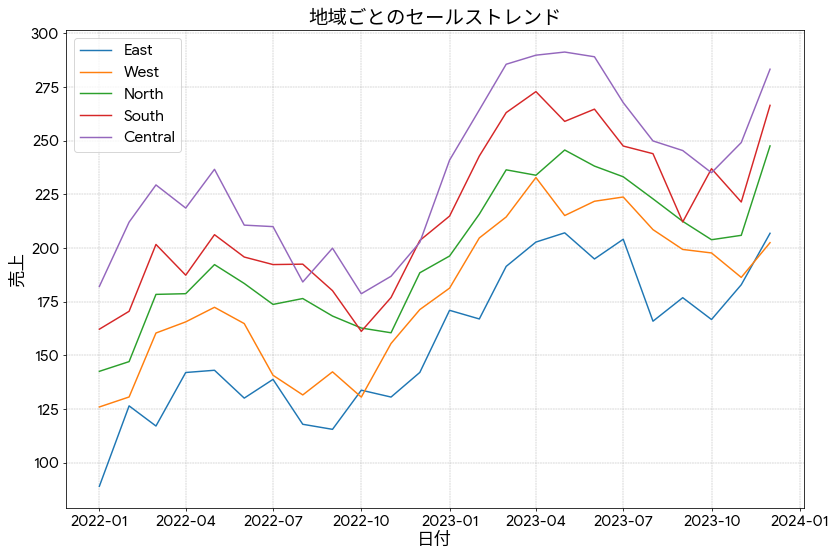

In [63]:
artifact_service = artifact_service_builder()
image_part = await artifact_service.load_artifact(
    app_name = 'root_agent',
    user_id = chat_client.user_id,
    session_id = chat_client.session_id,
    filename = 'output_plot.png'
)
display(Image.open(io.BytesIO(image_part.inline_data.data)))

In [64]:
session = await adk_app.async_get_session(
    user_id = chat_client.user_id,
    session_id = chat_client.session_id,
)    

In [65]:
session.state['qa_result']

{'interpreted_intent': 'To visualize the sales trend over time, broken down by region, across all available years to identify characteristic fluctuations.',
 'visualization_type': 'line chart',
 'plotting_key_points': ['Chart Type: Line chart to display trends over time.',
  "X-axis: 'Date' column, representing time (all years). This should be treated as a temporal axis.",
  "Y-axis: 'Sales' column, representing sales values.",
  "Categorical grouping: 'Region' column, with each region represented by a distinct line (e.g., different color).",
  "Title: '地域ごとのセールストレンド' (Sales Trend by Region).",
  "X-axis Label: '日付' (Date).",
  "Y-axis Label: '売上' (Sales).",
  "Legend: A legend clearly indicating each region's line.",
  'The visualization should facilitate comparison of sales changes across regions to identify unique patterns or fluctuations.'],
 'implementation_plan': [{'step': 1,
   'action': 'Load Data and Initial Preprocessing',
   'details': "Load the 'sales_data.csv' file into a 

In [66]:
session.state['dp_result']

{'processing_steps': ["Load 'sales_data.csv' into a pandas DataFrame.",
  "Convert the 'Date' column to datetime objects to ensure proper time-series plotting."],
 'insights': {'key_columns': ['Date', 'Region', 'Sales'],
  'aggregations_needed': [],
  'quality_issues': ["The 'Date' column needs to be converted to a datetime type for proper temporal analysis."]},
 'visualization_hint': 'line chart'}

In [67]:
session.state['vm_result']

{'chart_type': 'line',
 'data_mappings': {'x_axis': 'Date', 'y_axis': 'Sales', 'color': 'Region'},
 'aggregations': [],
 'filters': [],
 'styling_hints': {'title': '地域ごとのセールストレンド', 'xlabel': '日付', 'ylabel': '売上'},
 'transformations': ["df['Date'] = pd.to_datetime(df['Date'])"],
 'goal': 'To visualize the sales trend over time, broken down by region, across all available years to identify characteristic fluctuations.',
 'rationale': "A line chart is ideal for showing trends over time. Mapping 'Date' to the x-axis, 'Sales' to the y-axis, and using 'Region' for color allows for clear comparison of sales fluctuations across different regions, fulfilling the user's intent to identify characteristic fluctuations by region.",
 'confidence': 1.0}

In [68]:
session.state['design_result']

{'design_objectives': ['Clearly visualize sales trends over time for each region.',
  'Enable easy comparison of sales fluctuations between different regions.',
  'Provide a professional and legible chart suitable for business analysis.',
  'Highlight characteristic fluctuations in regional sales.'],
 'target_audience': {'primary_audience': 'Business stakeholders and analysts',
  'expertise_level': 'intermediate',
  'context_of_use': 'reporting',
  'accessibility_requirements': ['General readability',
   'Colorblind friendly (distinct colors for regions)']},
 'visual_hierarchy': {'primary_elements': ['Sales trend lines for each region',
   'Overall shape and direction of the trends'],
  'secondary_elements': ['Chart title',
   'Axis labels (日付, 売上)',
   'Legend for regions',
   'Tick marks and grid lines (if present)'],
  'emphasis_strategy': "Use distinct colors for each region's line, bold font for the title, and clear, uncluttered axis labeling to guide the eye to the trends."},
 'c

In [69]:
session.state['cg_result']

{'code_architecture': {'main_functions': ["The script's main logic is self-contained and does not require separate functions."],
  'helper_functions': [],
  'modular_design': 'The code is structured sequentially: data loading, data preparation, plotting, styling, and saving the output.'},
 'matplotlib_approach': {'plotting_method': 'object_oriented',
  'style_management': 'manual',
  'color_implementation': 'manual_colors',
  'layout_strategy': 'tight_layout'},
 'data_handling': {'data_preparation': ["Load 'sales_data.csv' into a pandas DataFrame.",
   "Convert the 'Date' column to datetime objects using pd.to_datetime."],
  'data_validation': [],
  'error_handling': [],
  'performance_considerations': ['The code iterates through unique regions to plot them, which is efficient for a small number of categories.']},
 'code_structure': {'imports': ['import pandas as pd',
   'import matplotlib.pyplot as plt'],
  'configuration': "df = pd.read_csv('sales_data.csv')\ndf['Date'] = pd.to_datet

In [70]:
chat_client = ChatClient(adk_app)

with open('sales_data.csv', 'rb') as f:
    csv_bytes = f.read()

message_input = {
    'role': 'user',
    'parts': [
        {'text': '2022年と2023年、それぞれの年度における地域ごとの売り上げの割合を見たい。アナリストに提出する企業レポートに使用します。'},
        {
            'inline_data': {
                'mime_type': 'text/csv',
                'data': csv_bytes,
                'display_name': 'sales_data.csv',
            }
        },
    ]
}

response = await chat_client.async_stream_query(message_input)

### root_agent
承知いたしました。以下に、ご提供いただいた情報をまとめました。

*   **可視化クエリ**: 2022年と2023年、それぞれの年度における地域ごとの売り上げの割合を見たい。
*   **可視化のコンテキスト**: アナリストに提出する企業レポートに使用します。
*   **データファイル**: `sales_data.csv`

これからチャートの作成プロセスを開始します。


### query_analyzer
{
  "interpreted_intent": "The user wants to visualize the sales proportion by region for the years 2022 and 2023. The visualization should allow for a comparison of regional sales distribution between these two years.",
  "visualization_type": "Donut Chart",
  "plotting_key_points": [
    "Chart Type: Two separate donut charts (or pie charts), one for each year (2022 and 2023).",
    "Data Source: 'sales_data.csv'.",
    "Columns to use: 'Date', 'Region', 'Sales'.",
    "Data Processing: Extract year from 'Date' column.",
    "Data Processing: Filter data for 2022 and 2023.",
    "Data Processing: For each year, calculate the total sales for each 'Region'.",
    "Data Processing: For each year, calculate the percentage of regional sales relative to the total sales for that year.",
    "Labels: Each slice of the donut chart should be labeled with the region name and its corresponding percentage.",
    "Titles: Each donut chart should have a clear title indicating the year (e.g., '2022年 地域別売上割合', '2023年 地域別売上割合').",
    "Colors: Use distinct colors for each region, consistent across both charts for easy comparison.",
    "Context: The visualization is for a corporate report, so a clean, professional, and easily understandable design is crucial."
  ],
  "implementation_plan": [
    {
      "step": 1,
      "action": "Load and prepare data",
      "details": "Load the 'sales_data.csv' file. Convert the 'Date' column to datetime objects and extract the 'Year'. Filter the data to include only records from 2022 and 2023. Calculate the total sales per region for each year, and then compute the percentage of each region's sales out of the total annual sales.",
      "functions": ["pd.read_csv", "pd.to_datetime", "df['Date'].dt.year", "df.groupby().sum()"]
    },
    {
      "step": 2,
      "action": "Design visualization elements",
      "details": "Determine appropriate chart types (donut charts), color palette for regions, title and label text in Japanese, and overall layout for displaying two comparative charts side-by-side or stacked.",
      "functions": []
    },
    {
      "step": 3,
      "action": "Generate visualization code",
      "details": "Write Python code using a suitable library (e.g., Matplotlib, Seaborn, Altair) to create two donut charts based on the processed data. Implement the calculated percentages, region labels, and titles as per the design. Ensure clear distinction between the two years and legibility of all elements.",
      "functions": ["plt.figure", "plt.pie", "plt.title", "plt.axis", "plt.text"]
    },
    {
      "step": 4,
      "action": "Review and refine visualization",
      "details": "Evaluate the generated charts against the user's query and context. Check for accuracy of percentages, clarity of labels, appropriateness of colors, and overall visual appeal for a corporate report. Make any necessary adjustments to improve readability and impact.",
      "functions": []
    }
  ],
  "global_todo_list": [
    {
      "id": "todo_1",
      "task": "Load 'sales_data.csv', parse 'Date' column to extract 'Year', filter for 2022 and 2023, then calculate regional sales sums and their percentages for each year.",
      "agent": "data_process_planner"
    },
    {
      "id": "todo_2",
      "task": "Map the processed regional sales percentages for 2022 and 2023 to two separate donut charts. Define 'Region' as the categorical variable for slices and 'Percentage' as the value. Ensure consistent color mapping for regions across both charts.",
      "agent": "viz_mapping_agent"
    },
    {
      "id": "todo_3",
      "task": "Develop a design strategy for two comparative donut charts, including a professional color scheme, clear Japanese titles ('2022年 地域別売上割合', '2023年 地域別売上割合'), readable labels (region and percentage), and a layout suitable for a corporate report.",
      "agent": "design_explorer"
    },
    {
      "id": "todo_4",
      "task": "Generate Python code to create the two donut charts based on the data processing, visualization mapping, and design specifications. The code should produce high-quality, publication-ready figures.",
      "agent": "code_generator"
    },
    {
      "id": "todo_5",
      "task": "Evaluate the generated visualization for accuracy, clarity, and adherence to all requirements outlined in the user query and context. Verify that regional sales proportions for 2022 and 2023 are clearly represented and easily comparable.",
      "agent": "visual_evaluator"
    }
  ],
  "success_criteria": [
    "Two distinct donut charts are generated, one for 2022 and one for 2023.",
    "Each chart accurately displays the sales proportion of each region for its respective year.",
    "All labels, including region names and percentages, are clearly visible and legible.",
    "Chart titles are in Japanese and clearly indicate the year and content ('2022年 地域別売上割合', '2023年 地域別売上割合').",
    "The visualization is suitable for a corporate report, demonstrating professionalism and ease of understanding.",
    "Regional colors are consistent across both charts for better comparison."
  ]
}

### data_process_planner
{"processing_steps": ["Load the sales data.", "Convert the 'Date' column to datetime objects.", "Extract the 'Year' from the 'Date' column.", "Filter the data to include only records for the years 2022 and 2023.", "Group the data by 'Year' and 'Region', then calculate the sum of 'Sales' for each group.", "For each year, calculate the total sales and then compute the percentage of each region's sales relative to the total annual sales."], "insights": {"key_columns": ["Date", "Region", "Sales"], "aggregations_needed": ["Sum of Sales by Year and Region", "Percentage of regional sales out of total annual sales for each year"], "quality_issues": []}, "visualization_hint": "Donut Chart"}

### viz_mapping_agent
{
  "chart_type": "pie",
  "data_mappings": {
    "category": "Region_JP_name_placeholder_for_labels_and_colors_after_processing_to_ensure_consistent_coloring_across_charts_by_region_name_like_East_or_West_etc. For the actual chart, the slice labels should include Region Name and Percentage, with Region mapping to color for distinct regions, and the value (or angle) to Percentage for slice size. This is a conceptual mapping to guide the plotting of regional sales percentages onto pie slices, where each unique region will get a distinct color and each slice's size will correspond to its percentage value. In the code, this will translate to 'Region' for color and labels, and 'Percentage' for the angle/value of the pie slices. The "
  },
  "aggregations": [
    {
      "operation": "sum",
      "column": "Sales",
      "group_by": "Region"
    }
  ],
  "filters": [
    {
      "column": "Year",
      "condition": "in [2022, 2023]"
    }
  ],
  "styling_hints": {
    "title": "地域別売上割合",
    "color_palette": "tableau10"
  },
  "transformations": [
    "df['Year'] = pd.to_datetime(df['Date']).dt.year",
    "df = df[df['Year'].isin([2022, 2023])]",
    "df_regional_sales = df.groupby(['Year', 'Region'])['Sales'].sum().reset_index()",
    "df_total_sales_by_year = df_regional_sales.groupby('Year')['Sales'].transform('sum')",
    "df_regional_sales['Percentage'] = (df_regional_sales['Sales'] / df_total_sales_by_year) * 100"
  ],
  "goal": "Visualize the sales proportion by region for the years 2022 and 2023 to compare regional sales distribution between these two years using two separate donut charts.",
  "rationale": "Donut charts (represented as 'pie' chart type with styling for the 'hole') are chosen as specified in the query and are suitable for displaying proportions of a whole. Two separate charts will be generated, one for each year (2022 and 2023), allowing for a direct comparison of regional sales distribution over time. The 'Region' column will be used for categorical mapping (color and labels), and the calculated 'Percentage' will determine the size of each slice. The data processing steps ensure that the sales are aggregated by region and year, and then converted into percentages relative to the total sales of each year, fulfilling the key requirements. Specific Japanese titles for each year ('2022年 地域別売上割合', '2023年 地域別売上割合') will be applied to the respective charts during the code generation phase.",
  "confidence": 1.0
}

### design_explorer
{
  "design_objectives": [
    "Ensure clear and easy comparison of regional sales proportions between 2022 and 2023.",
    "Present data in a professional and clean manner suitable for a corporate report.",
    "Maximize readability and immediate understanding of sales distribution.",
    "Maintain consistency in visual elements across both charts to facilitate direct comparison."
  ],
  "target_audience": {
    "primary_audience": "Analysts and Corporate Stakeholders",
    "expertise_level": "intermediate",
    "context_of_use": "reporting",
    "accessibility_requirements": [
      "Colorblind friendly palette",
      "Legible text sizes"
    ]
  },
  "visual_hierarchy": {
    "primary_elements": [
      "Donut chart slices (representing regional sales proportion)",
      "Chart titles ('2022年 地域別売上割合', '2023年 地域別売上割合')",
      "Percentage labels within or near slices"
    ],
    "secondary_elements": [
      "Region names (labels)",
      "Overall chart layout for comparison"
    ],
    "emphasis_strategy": "Use distinct, consistent colors for regions, prominent sizing for percentage labels, and clear visual separation of the two yearly charts to highlight changes and facilitate comparison."
  },
  "color_strategy": {
    "primary_colors": [
      "#1f77b4",
      "#ff7f0e",
      "#2ca02c",
      "#d62728",
      "#9467bd"
    ],
    "color_meaning": "Colors are used to differentiate regions. Consistency in color assignment for each region across both charts is paramount for comparison. The chosen palette (derived from Tableau 10) is designed for distinctness and general colorblind-friendliness.",
    "accessibility_compliance": "WCAG 2.1 AA (targeting contrast and color differentiation)",
    "cultural_considerations": null
  },
  "layout_principles": {
    "composition_approach": "balanced",
    "spacing_strategy": "moderate",
    "alignment_system": "center",
    "proportion_ratios": "custom"
  },
  "typography_requirements": {
    "font_hierarchy": "Chart titles will be the largest text, followed by percentage labels, then region names. All text should be clear and readable at a glance.",
    "readability_priority": "high",
    "brand_alignment": "corporate"
  },
  "interaction_design": {
    "interaction_level": "static",
    "user_controls": [],
    "feedback_mechanisms": "None"
  },
  "technical_constraints": {
    "output_format": "static",
    "size_limitations": "print",
    "performance_requirements": "detailed"
  },
  "innovation_opportunities": [
    "Subtle use of corporate branding elements (e.g., specific font if available) to align with the report's visual identity, without compromising clarity.",
    "Optimization of label placement to avoid overlap and maintain legibility, especially for smaller slices."
  ],
  "design_confidence": 1.0
}

### code_generator
{
  "code_architecture": {
    "main_functions": [
      "A main script block that handles data loading, processing, and plotting."
    ],
    "helper_functions": [],
    "class_structure": null,
    "modular_design": "The code is structured sequentially: 1. Data loading and preparation. 2. Definition of visualization parameters (colors, figure size). 3. A loop to generate a plot for each year. 4. Finalization and saving the output."
  },
  "matplotlib_approach": {
    "plotting_method": "plt.subplots",
    "style_management": "manual",
    "color_implementation": "manual_colors",
    "layout_strategy": "tight_layout"
  },
  "data_handling": {
    "data_preparation": [
      "Load 'sales_data.csv' into a pandas DataFrame.",
      "Convert 'Date' column to datetime objects.",
      "Extract 'Year' from the 'Date' column.",
      "Filter data for years 2022 and 2023.",
      "Group data by 'Year' and 'Region' and sum the 'Sales'.",
      "Calculate the percentage of total sales for each region within each year."
    ],
    "data_validation": [
      "Use .dropna() on the yearly data to handle any regions that might have no sales in a given year."
    ],
    "error_handling": [],
    "performance_considerations": [
      "The script is designed for a small dataset and runs efficiently without special performance optimizations."
    ]
  },
  "code_structure": {
    "imports": [
      "import pandas as pd",
      "import matplotlib.pyplot as plt"
    ],
    "configuration": "df = pd.read_csv('sales_data.csv')\ndf['Date'] = pd.to_datetime(df['Date'])\ndf['Year'] = df['Date'].dt.year\ndf_filtered = df[df['Year'].isin([2022, 2023])]\nsales_by_year_region = df_filtered.groupby(['Year', 'Region'])['Sales'].sum().unstack()\nsales_percentage = sales_by_year_region.div(sales_by_year_region.sum(axis=1), axis=0) * 100",
    "main_plotting": "fig, axes = plt.subplots(1, 2, figsize=(18, 9))\nall_regions = sorted(df_filtered['Region'].unique())\ncolors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']\nregion_colors = {region: color for region, color in zip(all_regions, colors)}\nyears = [2022, 2023]\nfor i, year in enumerate(years):\n    ax = axes[i]\n    data = sales_percentage.loc[year].dropna()\n    regions = data.index\n    pie_colors = [region_colors[region] for region in regions]\n    wedges, texts, autotexts = ax.pie(\n        data,\n        autopct='%1.1f%%',\n        startangle=90,\n        colors=pie_colors,\n        labels=regions,\n        textprops={'fontsize': 16},\n        pctdistance=0.8,\n        wedgeprops=dict(width=0.4, edgecolor='w')\n    )",
    "customization": "plt.setp(autotexts, size=16, weight=\"bold\", color=\"white\")\nax.set_title(f'{year}年 地域別売上割合', fontsize=20, pad=20)\nax.axis('equal')",
    "output_handling": "plt.tight_layout()\nplt.savefig('output_plot.png', format='png', dpi=70)\nplt.close('all')"
  },
  "quality_requirements": {
    "code_style": "PEP8",
    "documentation_level": "standard",
    "error_handling_level": "basic",
    "performance_priority": "readability"
  },
  "generated_code": "\nimport pandas as pd\nimport matplotlib.pyplot as plt\n\n# Load and prepare data\ndf = pd.read_csv('sales_data.csv')\ndf['Date'] = pd.to_datetime(df['Date'])\ndf['Year'] = df['Date'].dt.year\ndf_filtered = df[df['Year'].isin([2022, 2023])]\n\n# Calculate sales percentages\nsales_by_year_region = df_filtered.groupby(['Year', 'Region'])['Sales'].sum().unstack()\nsales_percentage = sales_by_year_region.div(sales_by_year_region.sum(axis=1), axis=0) * 100\n\n# Create subplots\nfig, axes = plt.subplots(1, 2, figsize=(18, 9))\n\n# Define consistent colors for regions\nall_regions = sorted(df_filtered['Region'].unique())\ncolors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']\nregion_colors = {region: color for region, color in zip(all_regions, colors)}\n\nyears = [2022, 2023]\n\nfor i, year in enumerate(years):\n    ax = axes[i]\n    data = sales_percentage.loc[year].dropna()\n    regions = data.index\n    pie_colors = [region_colors[region] for region in regions]\n\n    # Create the donut chart\n    wedges, texts, autotexts = ax.pie(\n        data,\n        autopct='%1.1f%%',\n        startangle=90,\n        colors=pie_colors,\n        labels=regions,\n        textprops={'fontsize': 16},\n        pctdistance=0.8, # Place percentages inside the wedges\n        wedgeprops=dict(width=0.4, edgecolor='w')\n    )\n\n    # Style the percentage text\n    plt.setp(autotexts, size=16, weight=\"bold\", color=\"white\")\n\n    # Set subplot title\n    ax.set_title(f'{year}年 地域別売上割合', fontsize=20, pad=20)\n    ax.axis('equal')\n\n# Final layout adjustments and save\nplt.tight_layout()\nplt.savefig('output_plot.png', format='png', dpi=70)\nplt.close('all')\n"
}

### transfer_agent
#### Pipeline execution result:
* Available Data Files: ['sales_data.csv']

* Result from the `query_analyser`:
{'interpreted_intent': 'The user wants to visualize the sales proportion by region for the years 2022 and 2023. The visualization should allow for a comparison of regional sales distribution between these two years.', 'visualization_type': 'Donut Chart', 'plotting_key_points': ['Chart Type: Two separate donut charts (or pie charts), one for each year (2022 and 2023).', "Data Source: 'sales_data.csv'.", "Columns to use: 'Date', 'Region', 'Sales'.", "Data Processing: Extract year from 'Date' column.", 'Data Processing: Filter data for 2022 and 2023.', "Data Processing: For each year, calculate the total sales for each 'Region'.", 'Data Processing: For each year, calculate the percentage of regional sales relative to the total sales for that year.', 'Labels: Each slice of the donut chart should be labeled with the region name and its corresponding percentage.', "Titles: Each donut chart should have a clear title indicating the year (e.g., '2022年 地域別売上割合', '2023年 地域別売上割合').", 'Colors: Use distinct colors for each region, consistent across both charts for easy comparison.', 'Context: The visualization is for a corporate report, so a clean, professional, and easily understandable design is crucial.'], 'implementation_plan': [{'step': 1, 'action': 'Load and prepare data', 'details': "Load the 'sales_data.csv' file. Convert the 'Date' column to datetime objects and extract the 'Year'. Filter the data to include only records from 2022 and 2023. Calculate the total sales per region for each year, and then compute the percentage of each region's sales out of the total annual sales.", 'functions': ['pd.read_csv', 'pd.to_datetime', "df['Date'].dt.year", 'df.groupby().sum()']}, {'step': 2, 'action': 'Design visualization elements', 'details': 'Determine appropriate chart types (donut charts), color palette for regions, title and label text in Japanese, and overall layout for displaying two comparative charts side-by-side or stacked.', 'functions': []}, {'step': 3, 'action': 'Generate visualization code', 'details': 'Write Python code using a suitable library (e.g., Matplotlib, Seaborn, Altair) to create two donut charts based on the processed data. Implement the calculated percentages, region labels, and titles as per the design. Ensure clear distinction between the two years and legibility of all elements.', 'functions': ['plt.figure', 'plt.pie', 'plt.title', 'plt.axis', 'plt.text']}, {'step': 4, 'action': 'Review and refine visualization', 'details': "Evaluate the generated charts against the user's query and context. Check for accuracy of percentages, clarity of labels, appropriateness of colors, and overall visual appeal for a corporate report. Make any necessary adjustments to improve readability and impact.", 'functions': []}], 'global_todo_list': [{'id': 'todo_1', 'task': "Load 'sales_data.csv', parse 'Date' column to extract 'Year', filter for 2022 and 2023, then calculate regional sales sums and their percentages for each year.", 'agent': 'data_process_planner'}, {'id': 'todo_2', 'task': "Map the processed regional sales percentages for 2022 and 2023 to two separate donut charts. Define 'Region' as the categorical variable for slices and 'Percentage' as the value. Ensure consistent color mapping for regions across both charts.", 'agent': 'viz_mapping_agent'}, {'id': 'todo_3', 'task': "Develop a design strategy for two comparative donut charts, including a professional color scheme, clear Japanese titles ('2022年 地域別売上割合', '2023年 地域別売上割合'), readable labels (region and percentage), and a layout suitable for a corporate report.", 'agent': 'design_explorer'}, {'id': 'todo_4', 'task': 'Generate Python code to create the two donut charts based on the data processing, visualization mapping, and design specifications. The code should produce high-quality, publication-ready figures.', 'agent': 'code_generator'}, {'id': 'todo_5', 'task': 'Evaluate the generated visualization for accuracy, clarity, and adherence to all requirements outlined in the user query and context. Verify that regional sales proportions for 2022 and 2023 are clearly represented and easily comparable.', 'agent': 'visual_evaluator'}], 'success_criteria': ['Two distinct donut charts are generated, one for 2022 and one for 2023.', 'Each chart accurately displays the sales proportion of each region for its respective year.', 'All labels, including region names and percentages, are clearly visible and legible.', "Chart titles are in Japanese and clearly indicate the year and content ('2022年 地域別売上割合', '2023年 地域別売上割合').", 'The visualization is suitable for a corporate report, demonstrating professionalism and ease of understanding.', 'Regional colors are consistent across both charts for better comparison.']}
* Result from the `data_process_planner`:
{'processing_steps': ['Load the sales data.', "Convert the 'Date' column to datetime objects.", "Extract the 'Year' from the 'Date' column.", 'Filter the data to include only records for the years 2022 and 2023.', "Group the data by 'Year' and 'Region', then calculate the sum of 'Sales' for each group.", "For each year, calculate the total sales and then compute the percentage of each region's sales relative to the total annual sales."], 'insights': {'key_columns': ['Date', 'Region', 'Sales'], 'aggregations_needed': ['Sum of Sales by Year and Region', 'Percentage of regional sales out of total annual sales for each year'], 'quality_issues': []}, 'visualization_hint': 'Donut Chart'}
* Result from the `viz_mapping_agent`:
{'chart_type': 'pie', 'data_mappings': {'category': "Region_JP_name_placeholder_for_labels_and_colors_after_processing_to_ensure_consistent_coloring_across_charts_by_region_name_like_East_or_West_etc. For the actual chart, the slice labels should include Region Name and Percentage, with Region mapping to color for distinct regions, and the value (or angle) to Percentage for slice size. This is a conceptual mapping to guide the plotting of regional sales percentages onto pie slices, where each unique region will get a distinct color and each slice's size will correspond to its percentage value. In the code, this will translate to 'Region' for color and labels, and 'Percentage' for the angle/value of the pie slices. The "}, 'aggregations': [{'operation': 'sum', 'column': 'Sales', 'group_by': 'Region'}], 'filters': [{'column': 'Year', 'condition': 'in [2022, 2023]'}], 'styling_hints': {'title': '地域別売上割合', 'color_palette': 'tableau10'}, 'transformations': ["df['Year'] = pd.to_datetime(df['Date']).dt.year", "df = df[df['Year'].isin([2022, 2023])]", "df_regional_sales = df.groupby(['Year', 'Region'])['Sales'].sum().reset_index()", "df_total_sales_by_year = df_regional_sales.groupby('Year')['Sales'].transform('sum')", "df_regional_sales['Percentage'] = (df_regional_sales['Sales'] / df_total_sales_by_year) * 100"], 'goal': 'Visualize the sales proportion by region for the years 2022 and 2023 to compare regional sales distribution between these two years using two separate donut charts.', 'rationale': "Donut charts (represented as 'pie' chart type with styling for the 'hole') are chosen as specified in the query and are suitable for displaying proportions of a whole. Two separate charts will be generated, one for each year (2022 and 2023), allowing for a direct comparison of regional sales distribution over time. The 'Region' column will be used for categorical mapping (color and labels), and the calculated 'Percentage' will determine the size of each slice. The data processing steps ensure that the sales are aggregated by region and year, and then converted into percentages relative to the total sales of each year, fulfilling the key requirements. Specific Japanese titles for each year ('2022年 地域別売上割合', '2023年 地域別売上割合') will be applied to the respective charts during the code generation phase.", 'confidence': 1.0}
* Result from the `design_explorer`:
{'design_objectives': ['Ensure clear and easy comparison of regional sales proportions between 2022 and 2023.', 'Present data in a professional and clean manner suitable for a corporate report.', 'Maximize readability and immediate understanding of sales distribution.', 'Maintain consistency in visual elements across both charts to facilitate direct comparison.'], 'target_audience': {'primary_audience': 'Analysts and Corporate Stakeholders', 'expertise_level': 'intermediate', 'context_of_use': 'reporting', 'accessibility_requirements': ['Colorblind friendly palette', 'Legible text sizes']}, 'visual_hierarchy': {'primary_elements': ['Donut chart slices (representing regional sales proportion)', "Chart titles ('2022年 地域別売上割合', '2023年 地域別売上割合')", 'Percentage labels within or near slices'], 'secondary_elements': ['Region names (labels)', 'Overall chart layout for comparison'], 'emphasis_strategy': 'Use distinct, consistent colors for regions, prominent sizing for percentage labels, and clear visual separation of the two yearly charts to highlight changes and facilitate comparison.'}, 'color_strategy': {'primary_colors': ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd'], 'color_meaning': 'Colors are used to differentiate regions. Consistency in color assignment for each region across both charts is paramount for comparison. The chosen palette (derived from Tableau 10) is designed for distinctness and general colorblind-friendliness.', 'accessibility_compliance': 'WCAG 2.1 AA (targeting contrast and color differentiation)'}, 'layout_principles': {'composition_approach': 'balanced', 'spacing_strategy': 'moderate', 'alignment_system': 'center', 'proportion_ratios': 'custom'}, 'typography_requirements': {'font_hierarchy': 'Chart titles will be the largest text, followed by percentage labels, then region names. All text should be clear and readable at a glance.', 'readability_priority': 'high', 'brand_alignment': 'corporate'}, 'interaction_design': {'interaction_level': 'static', 'user_controls': [], 'feedback_mechanisms': 'None'}, 'technical_constraints': {'output_format': 'static', 'size_limitations': 'print', 'performance_requirements': 'detailed'}, 'innovation_opportunities': ["Subtle use of corporate branding elements (e.g., specific font if available) to align with the report's visual identity, without compromising clarity.", 'Optimization of label placement to avoid overlap and maintain legibility, especially for smaller slices.'], 'design_confidence': 1.0}
* Result from the `code_generator`:
{'code_architecture': {'main_functions': ['A main script block that handles data loading, processing, and plotting.'], 'helper_functions': [], 'modular_design': 'The code is structured sequentially: 1. Data loading and preparation. 2. Definition of visualization parameters (colors, figure size). 3. A loop to generate a plot for each year. 4. Finalization and saving the output.'}, 'matplotlib_approach': {'plotting_method': 'plt.subplots', 'style_management': 'manual', 'color_implementation': 'manual_colors', 'layout_strategy': 'tight_layout'}, 'data_handling': {'data_preparation': ["Load 'sales_data.csv' into a pandas DataFrame.", "Convert 'Date' column to datetime objects.", "Extract 'Year' from the 'Date' column.", 'Filter data for years 2022 and 2023.', "Group data by 'Year' and 'Region' and sum the 'Sales'.", 'Calculate the percentage of total sales for each region within each year.'], 'data_validation': ['Use .dropna() on the yearly data to handle any regions that might have no sales in a given year.'], 'error_handling': [], 'performance_considerations': ['The script is designed for a small dataset and runs efficiently without special performance optimizations.']}, 'code_structure': {'imports': ['import pandas as pd', 'import matplotlib.pyplot as plt'], 'configuration': "df = pd.read_csv('sales_data.csv')\ndf['Date'] = pd.to_datetime(df['Date'])\ndf['Year'] = df['Date'].dt.year\ndf_filtered = df[df['Year'].isin([2022, 2023])]\nsales_by_year_region = df_filtered.groupby(['Year', 'Region'])['Sales'].sum().unstack()\nsales_percentage = sales_by_year_region.div(sales_by_year_region.sum(axis=1), axis=0) * 100", 'main_plotting': "fig, axes = plt.subplots(1, 2, figsize=(18, 9))\nall_regions = sorted(df_filtered['Region'].unique())\ncolors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']\nregion_colors = {region: color for region, color in zip(all_regions, colors)}\nyears = [2022, 2023]\nfor i, year in enumerate(years):\n    ax = axes[i]\n    data = sales_percentage.loc[year].dropna()\n    regions = data.index\n    pie_colors = [region_colors[region] for region in regions]\n    wedges, texts, autotexts = ax.pie(\n        data,\n        autopct='%1.1f%%',\n        startangle=90,\n        colors=pie_colors,\n        labels=regions,\n        textprops={'fontsize': 16},\n        pctdistance=0.8,\n        wedgeprops=dict(width=0.4, edgecolor='w')\n    )", 'customization': 'plt.setp(autotexts, size=16, weight="bold", color="white")\nax.set_title(f\'{year}年 地域別売上割合\', fontsize=20, pad=20)\nax.axis(\'equal\')', 'output_handling': "plt.tight_layout()\nplt.savefig('output_plot.png', format='png', dpi=70)\nplt.close('all')"}, 'quality_requirements': {'code_style': 'PEP8', 'documentation_level': 'standard', 'error_handling_level': 'basic', 'performance_priority': 'readability'}, 'generated_code': '\nimport pandas as pd\nimport matplotlib.pyplot as plt\n\n# Load and prepare data\ndf = pd.read_csv(\'sales_data.csv\')\ndf[\'Date\'] = pd.to_datetime(df[\'Date\'])\ndf[\'Year\'] = df[\'Date\'].dt.year\ndf_filtered = df[df[\'Year\'].isin([2022, 2023])]\n\n# Calculate sales percentages\nsales_by_year_region = df_filtered.groupby([\'Year\', \'Region\'])[\'Sales\'].sum().unstack()\nsales_percentage = sales_by_year_region.div(sales_by_year_region.sum(axis=1), axis=0) * 100\n\n# Create subplots\nfig, axes = plt.subplots(1, 2, figsize=(18, 9))\n\n# Define consistent colors for regions\nall_regions = sorted(df_filtered[\'Region\'].unique())\ncolors = [\'#1f77b4\', \'#ff7f0e\', \'#2ca02c\', \'#d62728\', \'#9467bd\']\nregion_colors = {region: color for region, color in zip(all_regions, colors)}\n\nyears = [2022, 2023]\n\nfor i, year in enumerate(years):\n    ax = axes[i]\n    data = sales_percentage.loc[year].dropna()\n    regions = data.index\n    pie_colors = [region_colors[region] for region in regions]\n\n    # Create the donut chart\n    wedges, texts, autotexts = ax.pie(\n        data,\n        autopct=\'%1.1f%%\',\n        startangle=90,\n        colors=pie_colors,\n        labels=regions,\n        textprops={\'fontsize\': 16},\n        pctdistance=0.8, # Place percentages inside the wedges\n        wedgeprops=dict(width=0.4, edgecolor=\'w\')\n    )\n\n    # Style the percentage text\n    plt.setp(autotexts, size=16, weight="bold", color="white")\n\n    # Set subplot title\n    ax.set_title(f\'{year}年 地域別売上割合\', fontsize=20, pad=20)\n    ax.axis(\'equal\')\n\n# Final layout adjustments and save\nplt.tight_layout()\nplt.savefig(\'output_plot.png\', format=\'png\', dpi=70)\nplt.close(\'all\')\n'}


### root_agent
2022年と2023年の地域別売上割合を示す2つのドーナツチャートが正常に生成され、`output_plot.png` として保存されました。

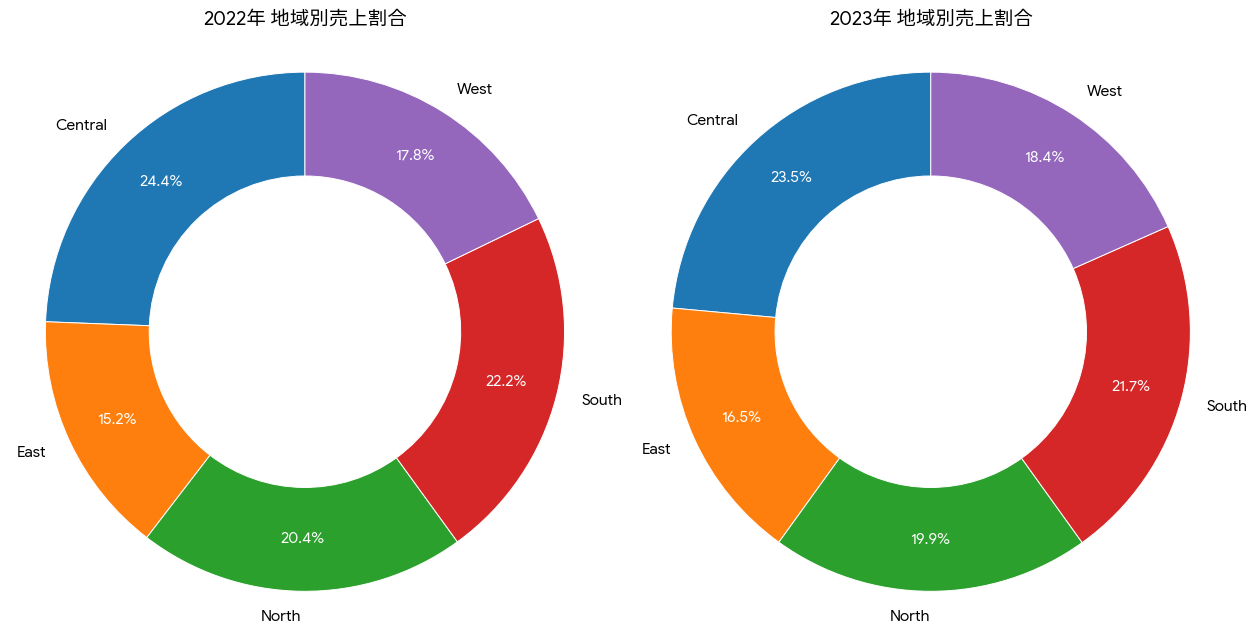

In [71]:
artifact_service = artifact_service_builder()
image_part = await artifact_service.load_artifact(
    app_name = 'root_agent',
    user_id = chat_client.user_id,
    session_id = chat_client.session_id,
    filename = 'output_plot.png'
)
display(Image.open(io.BytesIO(image_part.inline_data.data)))

In [72]:
session = await adk_app.async_get_session(
    user_id = chat_client.user_id,
    session_id = chat_client.session_id,
)    

In [73]:
session.state['qa_result']

{'interpreted_intent': 'The user wants to visualize the sales proportion by region for the years 2022 and 2023. The visualization should allow for a comparison of regional sales distribution between these two years.',
 'visualization_type': 'Donut Chart',
 'plotting_key_points': ['Chart Type: Two separate donut charts (or pie charts), one for each year (2022 and 2023).',
  "Data Source: 'sales_data.csv'.",
  "Columns to use: 'Date', 'Region', 'Sales'.",
  "Data Processing: Extract year from 'Date' column.",
  'Data Processing: Filter data for 2022 and 2023.',
  "Data Processing: For each year, calculate the total sales for each 'Region'.",
  'Data Processing: For each year, calculate the percentage of regional sales relative to the total sales for that year.',
  'Labels: Each slice of the donut chart should be labeled with the region name and its corresponding percentage.',
  "Titles: Each donut chart should have a clear title indicating the year (e.g., '2022年 地域別売上割合', '2023年 地域別売上割合'

In [74]:
session.state['dp_result']

{'processing_steps': ['Load the sales data.',
  "Convert the 'Date' column to datetime objects.",
  "Extract the 'Year' from the 'Date' column.",
  'Filter the data to include only records for the years 2022 and 2023.',
  "Group the data by 'Year' and 'Region', then calculate the sum of 'Sales' for each group.",
  "For each year, calculate the total sales and then compute the percentage of each region's sales relative to the total annual sales."],
 'insights': {'key_columns': ['Date', 'Region', 'Sales'],
  'aggregations_needed': ['Sum of Sales by Year and Region',
   'Percentage of regional sales out of total annual sales for each year'],
  'quality_issues': []},
 'visualization_hint': 'Donut Chart'}

In [75]:
session.state['vm_result']

{'chart_type': 'pie',
 'data_mappings': {'category': "Region_JP_name_placeholder_for_labels_and_colors_after_processing_to_ensure_consistent_coloring_across_charts_by_region_name_like_East_or_West_etc. For the actual chart, the slice labels should include Region Name and Percentage, with Region mapping to color for distinct regions, and the value (or angle) to Percentage for slice size. This is a conceptual mapping to guide the plotting of regional sales percentages onto pie slices, where each unique region will get a distinct color and each slice's size will correspond to its percentage value. In the code, this will translate to 'Region' for color and labels, and 'Percentage' for the angle/value of the pie slices. The "},
 'aggregations': [{'operation': 'sum',
   'column': 'Sales',
   'group_by': 'Region'}],
 'filters': [{'column': 'Year', 'condition': 'in [2022, 2023]'}],
 'styling_hints': {'title': '地域別売上割合', 'color_palette': 'tableau10'},
 'transformations': ["df['Year'] = pd.to_da

In [76]:
session.state['design_result']

{'design_objectives': ['Ensure clear and easy comparison of regional sales proportions between 2022 and 2023.',
  'Present data in a professional and clean manner suitable for a corporate report.',
  'Maximize readability and immediate understanding of sales distribution.',
  'Maintain consistency in visual elements across both charts to facilitate direct comparison.'],
 'target_audience': {'primary_audience': 'Analysts and Corporate Stakeholders',
  'expertise_level': 'intermediate',
  'context_of_use': 'reporting',
  'accessibility_requirements': ['Colorblind friendly palette',
   'Legible text sizes']},
 'visual_hierarchy': {'primary_elements': ['Donut chart slices (representing regional sales proportion)',
   "Chart titles ('2022年 地域別売上割合', '2023年 地域別売上割合')",
   'Percentage labels within or near slices'],
  'secondary_elements': ['Region names (labels)',
   'Overall chart layout for comparison'],
  'emphasis_strategy': 'Use distinct, consistent colors for regions, prominent sizing 

In [77]:
session.state['cg_result']

{'code_architecture': {'main_functions': ['A main script block that handles data loading, processing, and plotting.'],
  'helper_functions': [],
  'modular_design': 'The code is structured sequentially: 1. Data loading and preparation. 2. Definition of visualization parameters (colors, figure size). 3. A loop to generate a plot for each year. 4. Finalization and saving the output.'},
 'matplotlib_approach': {'plotting_method': 'plt.subplots',
  'style_management': 'manual',
  'color_implementation': 'manual_colors',
  'layout_strategy': 'tight_layout'},
 'data_handling': {'data_preparation': ["Load 'sales_data.csv' into a pandas DataFrame.",
   "Convert 'Date' column to datetime objects.",
   "Extract 'Year' from the 'Date' column.",
   'Filter data for years 2022 and 2023.',
   "Group data by 'Year' and 'Region' and sum the 'Sales'.",
   'Calculate the percentage of total sales for each region within each year.'],
  'data_validation': ['Use .dropna() on the yearly data to handle any r